# Plotting Gene Expression Based Results 

In [2]:
library(data.table)
library(stringr)
library(UpSetR)
library(ggplot2)
#library(clusterProfiler)
#library(org.Hs.eg.db)
library(grid)
library(gridExtra)
library(dplyr)
library(tidyr)
library(pheatmap)

In [3]:
# read in significant gene calls
UPM_sig_10 <- readRDS("../results/DESeq2/UPM_siggenes_DESeq2_GeneHK_p1e10.rds")
names(UPM_sig_10)
UPM_sig_20 <- readRDS("../results/DESeq2/UPM_siggenes_DESeq2_GeneHK_p1e20.rds")
names(UPM_sig_20)

WSP_sig_10 <- readRDS("../results/DESeq2/WSP_siggenes_DESeq2_GeneHK_p1e10.rds")
names(WSP_sig_10)
WSP_sig_20 <- readRDS("../results/DESeq2/WSP_siggenes_DESeq2_GeneHK_p1e20.rds")
names(WSP_sig_20)

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

## Timing Based Comparions

In [4]:
## EARLY and Temporary
get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall)
    return(time_sig)
    }
UPM_10_time_sig = get_timing_sig(UPM_sig_10)
UPM_20_time_sig = get_timing_sig(UPM_sig_20)

WSP_10_time_sig = get_timing_sig(WSP_sig_10)
WSP_20_time_sig = get_timing_sig(WSP_sig_20)

In [7]:
read_in_results <- function(filename, num_use=20) {
    res <- fread(filename)
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
     # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    start = nrow(neg_FC) - num_use - 1
    return(list("res"=full_res, "UP15"=pos_FC$V1[1:num_use], "DOWN15"=neg_FC$V1[start:nrow(neg_FC)], 
          "UPSIG"=pos_FC[pos_FC$padj < 1e-6,]$V1, "DOWNSIG"=neg_FC[neg_FC$padj < 1e-6,]$V1))
    }

In [8]:
res_ADP_list <- read_in_results("../results/DESeq2/res_Gene_ADP_vs_Veh_par_rat_Wd_GeneHK.txt")
res_W120_list <- read_in_results("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")
res_W30_list <- read_in_results("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")
res_U120_list <- read_in_results("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")
res_U30_list <- read_in_results("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")

Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (es decir, un archivo no v'alido). Se agrega/n 1 nombre(s) predeterminado(s) adicional/es de columna para la primera columna que se supone que son nombres de filas o un 'indice. Utilice setnames() despu'es si esta suposici'on no es correcta, o corrija el comando de escritura de archivo que cre'o el archivo para crear un archivo v'alido."
Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (es decir, un archivo no v'alido). Se agrega/n 1 nombre(s) predeterminado(s) adicional/es de columna para la primera columna que se supone que son nombres de filas o un 'indice. Utilice setnames() despu'es si esta suposici'on no es correcta, o corrija el comando de escritura de archivo que cre'o el archivo para crear un archivo v'alido."
Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (e

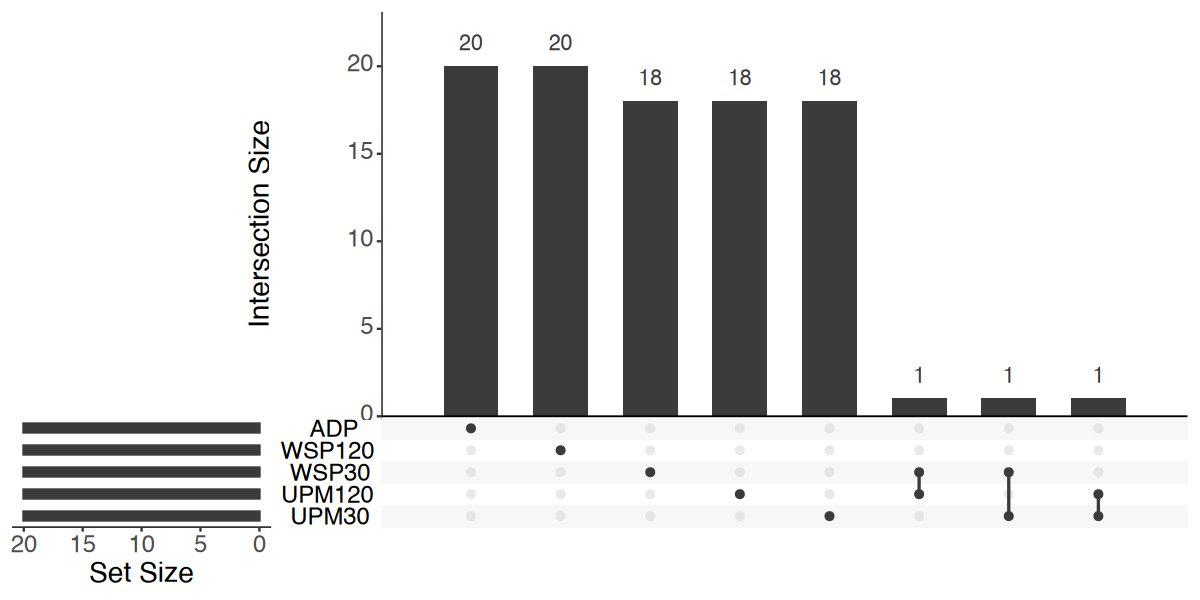

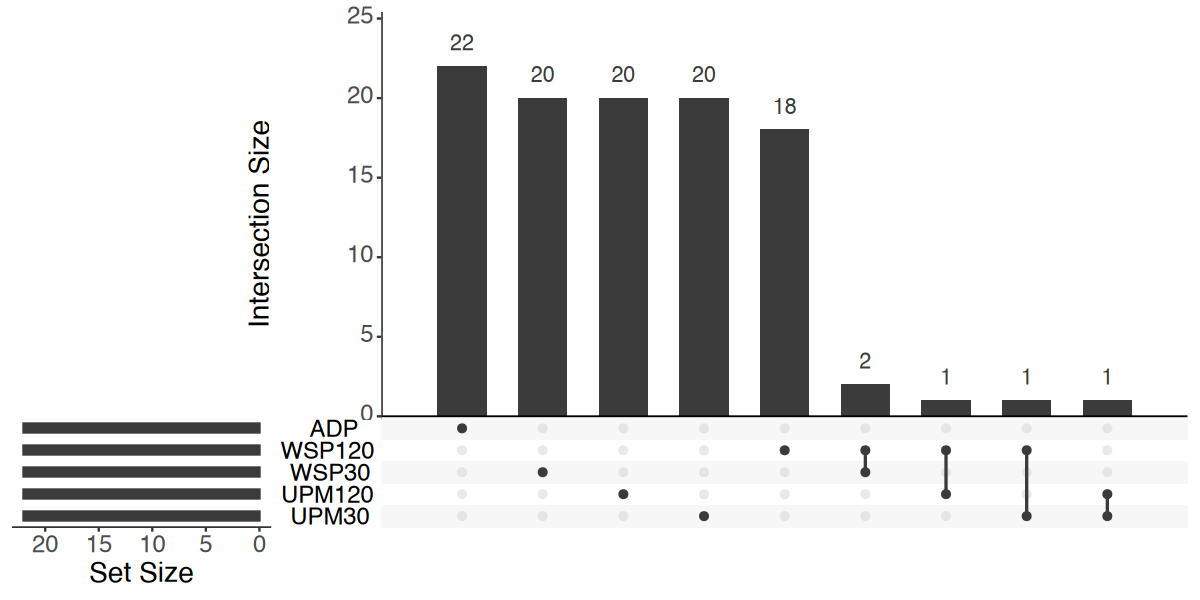

In [7]:
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(list("ADP"=res_ADP_list$UP15, "WSP120"=res_W120_list$UP15, "WSP30"=res_W30_list$UP15, 
                    "UPM120"=res_U120_list$UP15, "UPM30"=res_U30_list$UP15)), text.scale=2, nsets=5)

upset(fromList(list("ADP"=res_ADP_list$DOWN15, "WSP120"=res_W120_list$DOWN15, "WSP30"=res_W30_list$DOWN15, 
                    "UPM120"=res_U120_list$DOWN15, "UPM30"=res_U30_list$DOWN15)), text.scale=2, nsets=5)

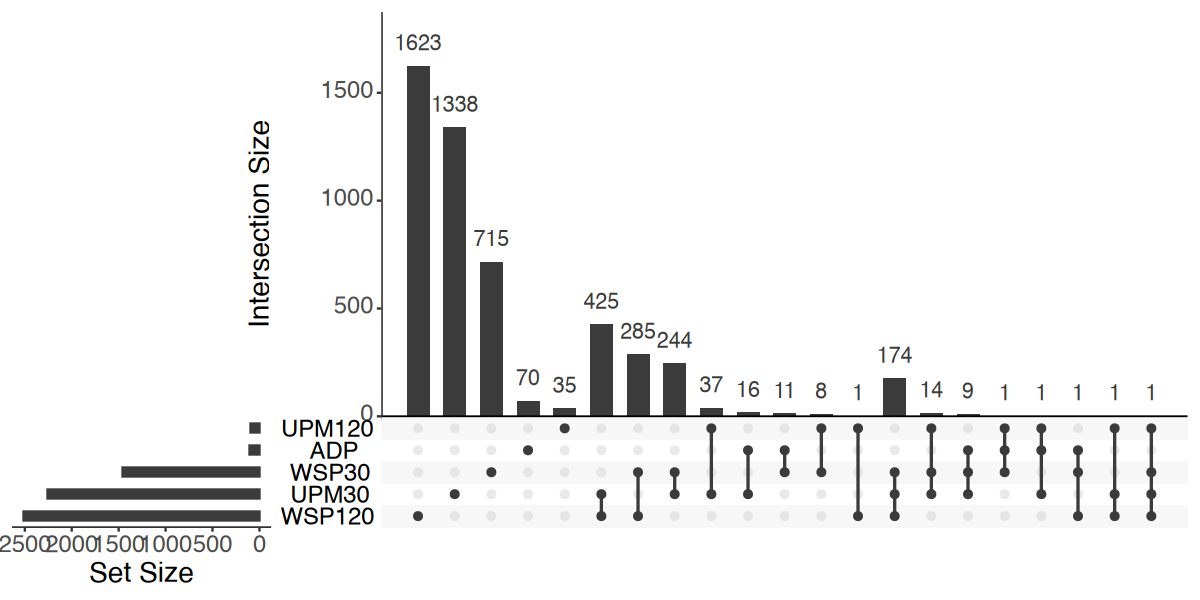

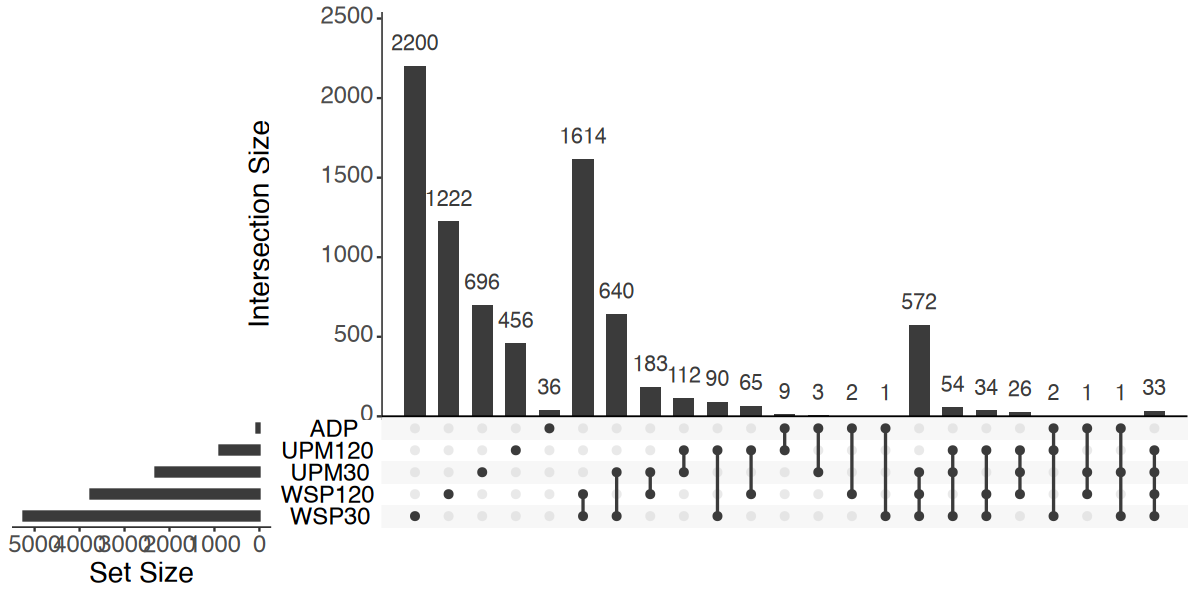

In [16]:
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(list("ADP"=res_ADP_list$UPSIG, "WSP120"=res_W120_list$UPSIG, "WSP30"=res_W30_list$UPSIG, 
                    "UPM120"=res_U120_list$UPSIG, "UPM30"=res_U30_list$UPSIG)), text.scale=2, nsets=5)

upset(fromList(list("ADP"=res_ADP_list$DOWNSIG, "WSP120"=res_W120_list$DOWNSIG, "WSP30"=res_W30_list$DOWNSIG, 
                    "UPM120"=res_U120_list$DOWNSIG, "UPM30"=res_U30_list$DOWNSIG)), text.scale=2, nsets=5)

In [9]:
# add info about Perturbation and timing
res_ADP_list$res$Source <- "ADP"
res_ADP_list$res$Time <- "20h"
res_W120_list$res$Source <- "WSP"
res_W120_list$res$Time <- "120m"
res_W30_list$res$Source <- "WSP"
res_W30_list$res$Time <- "30m"
res_U120_list$res$Source <- "UPM"
res_U120_list$res$Time <- "120m"
res_U30_list$res$Source <- "UPM"
res_U30_list$res$Time <- "30m"

plot_df <- rbind(res_ADP_list$res, rbind(res_W120_list$res, rbind(res_W30_list$res, rbind(res_U120_list$res, res_U30_list$res))))
plot_df[1:2,]

plot_df$Sig <- "NonSig"
plot_df[plot_df$padj < 1e-6,]$Sig <- "Sig"
plot_df$Source_Time <- paste0(plot_df$Source, "_", plot_df$Time)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Source,Time
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
TIMP2,1959.9858,4.292117,0.3218790,13.33457,1.456995e-40,1.225260e-36,ADP,20h
SPNS2,747.7767,4.408191,0.3388989,13.00739,1.110688e-38,6.226888e-35,ADP,20h


In [32]:
#plot_df[order(plot_df$padj)]

In [9]:
# Get the UPM genes with the greatest signfiicance across the different time points
names(UPM_10_time_sig)

top_genes = list()


for (timepoint in names(UPM_10_time_sig)) {
    if (timepoint %in% c("ER", "EF", "EPR", "EPF")) {
    filt = res_U30_list$res[res_U30_list$res$V1 %in% UPM_time_sig[[timepoint]],]
    # get top two by p-value sig
    top_genes[[timepoint]] = filt[order(filt$padj, -filt$log2FoldChange),]$V1[1:2]
    } else if  (timepoint %in% c("LR", "LF")) {
    filt = res_U120_list$res[res_U120_list$res$V1 %in% UPM_time_sig[[timepoint]],]
    # get top two by p-value sig
    top_genes[[timepoint]] = filt[order(filt$padj, -filt$log2FoldChange),]$V1[1:2]
    } else {print("ERROR")}
    }

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

ERROR: Error in .checkTypos(e, names_x): Objeto 'UPM_time_sig' no encontrado entre [V1, baseMean, log2FoldChange, lfcSE, stat, pvalue, padj, Source, Time]


In [8]:
top_genes

list()

### Plotting L2FC

In [10]:
use_genes = unlist(top_genes)
color_map = c("ADP"="wheat2", "WSP"="tomato", "UPM"="grey")
#* No clear signal for HAPLN (HYA binding proteins)

height_use = 4
height_use
options(repr.plot.height=height_use, repr.plot.width=6.5)
setdiff(use_genes, plot_df$V1)
pdf("UPM_LFC_spec_genes.pdf", height=height_use, width=6.5)
for (timepoint in names(top_genes)) {
    use_genes = top_genes[[timepoint]]
    plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
    plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle(timepoint) + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))  # top, right, bottom, left in pts
print(p)}
dev.off()

[1] 4

NULL

pdf 
  2

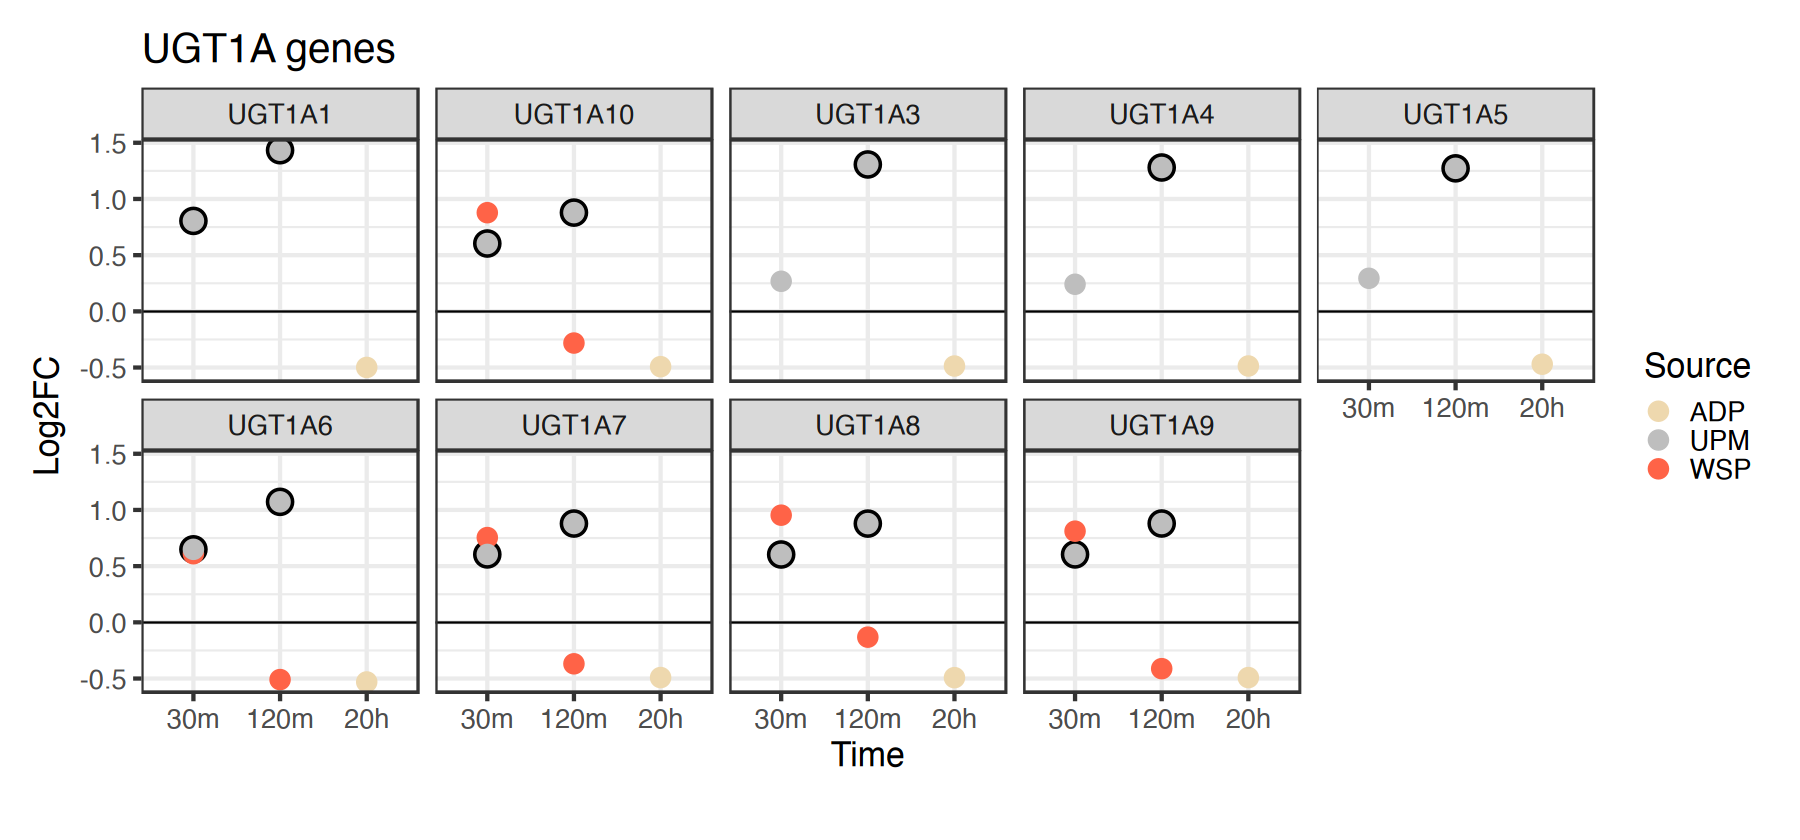

In [359]:
use_genes = c("UGT1A1", "UGT1A2", "UGT1A3", "UGT1A4", "UGT1A5", 
              "UGT1A6", "UGT1A7", "UGT1A8", "UGT1A9", "UGT1A10")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=7, repr.plot.width=15)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("UGT1A genes") + facet_wrap(~V1, nrow=2) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

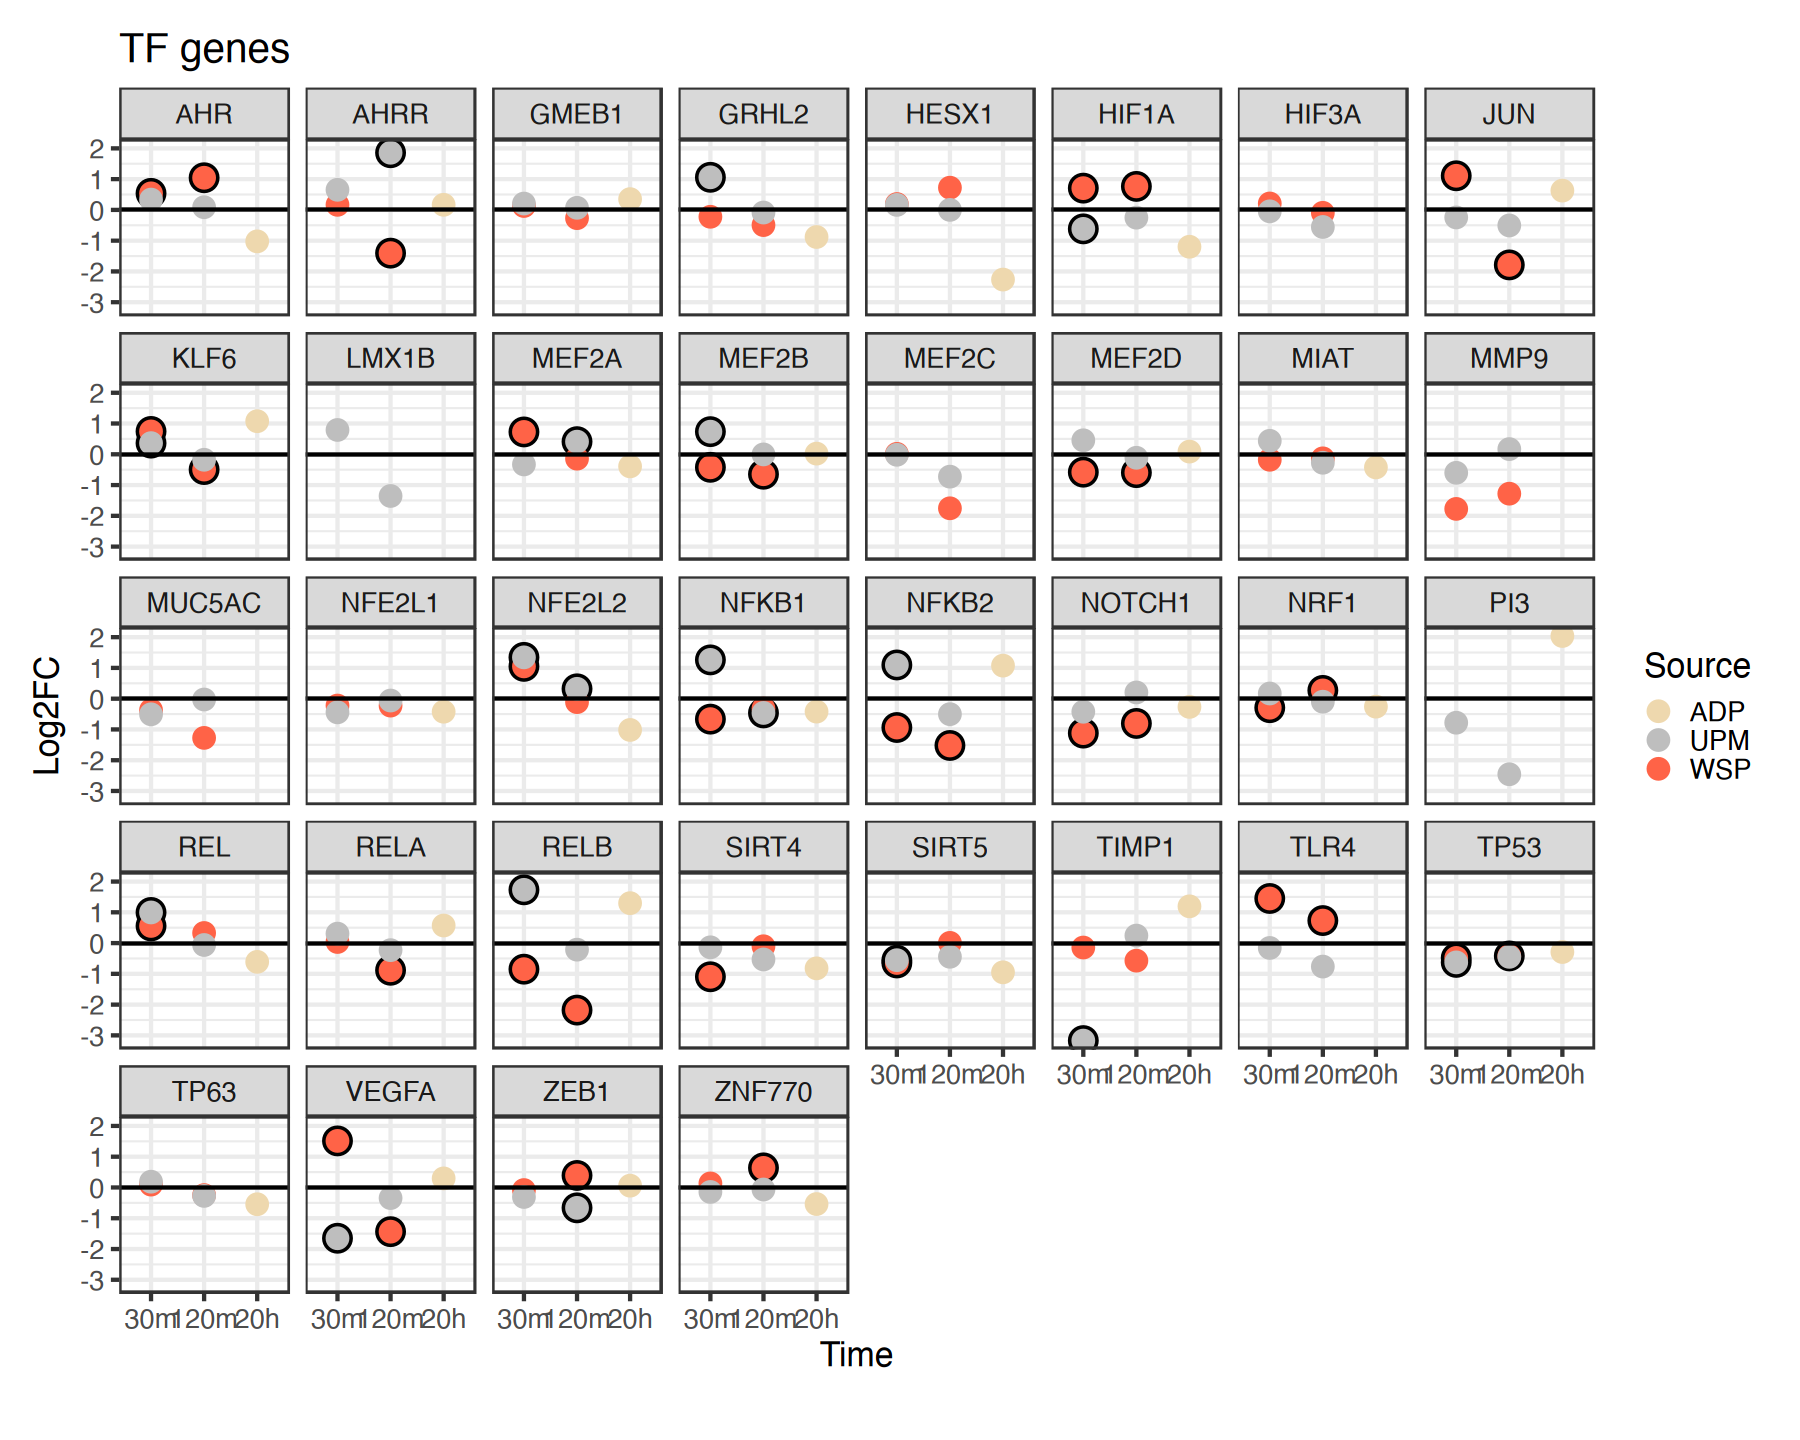

In [10]:
# TFs
color_map = c("ADP"="wheat2", "WSP"="tomato", "UPM"="grey")
tf_genes = c("JUND", "REL", "RELA", "RELB", "T65", "NFKB1", "NFKB2", 
              "TP53", "HIF3A", "HIF1A", "PI3", "MMP9",
			  "MIAT", "VEGFA", "HMOX", "MUC5AC", "GRHL2", 
			   "COX2", "TLR4", "TIMP1", "MEF2A", 
			  "MEF2B", "MEF2C", "MEF2D", "KLF6", "SIRT5", "SIRT4",
			  "NRF1", "NFE2L1", "NFE2L2", "AHRR", "AHR", "ZN770", "ZNF770",
			  "NOTCH1", "TP63", "ZEB1", "SNAIL1", "HESX1", 
			  "LMX1B", "ZN184", "GMEB1", "MYCN", "JUND", "JUNC", "JUN")
plot_df_use = plot_df[plot_df$V1 %in% tf_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=12, repr.plot.width=15)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("TF genes") + facet_wrap(~V1, nrow=5) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

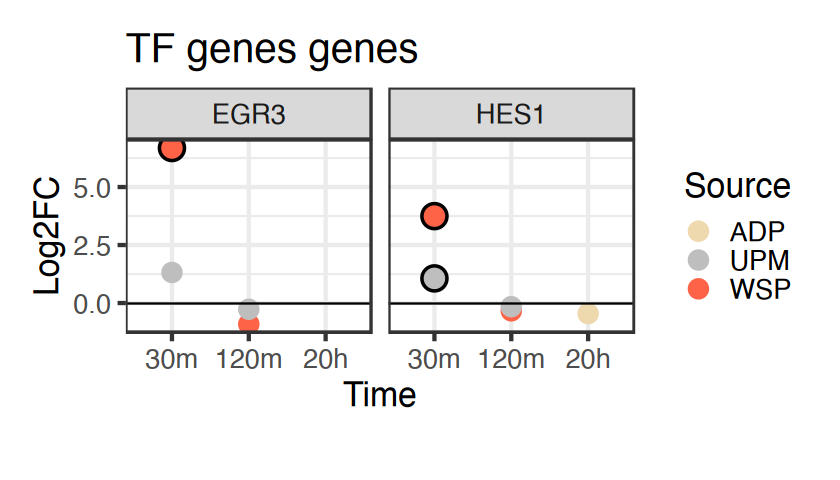

In [19]:
use_genes = c("EGR3", "HES1")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=4, repr.plot.width=7)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("TF genes genes") + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

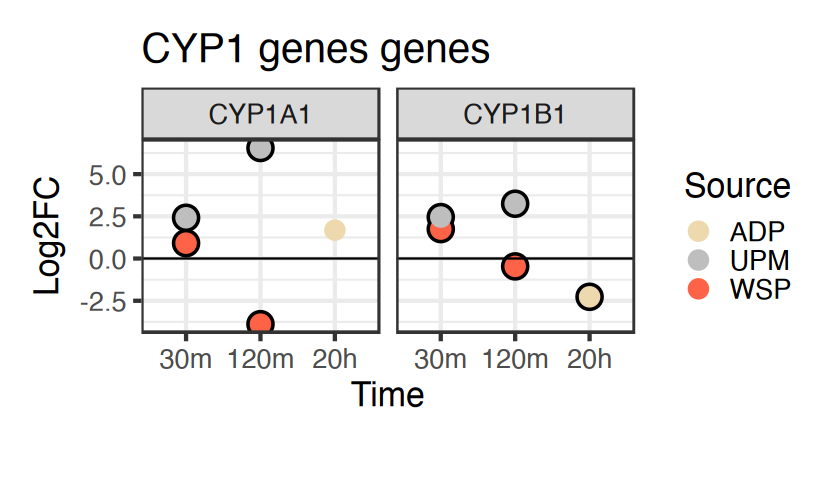

In [361]:
use_genes = c("CYP1A1", "CYP1B1")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=4, repr.plot.width=7)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("CYP1 genes genes") + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

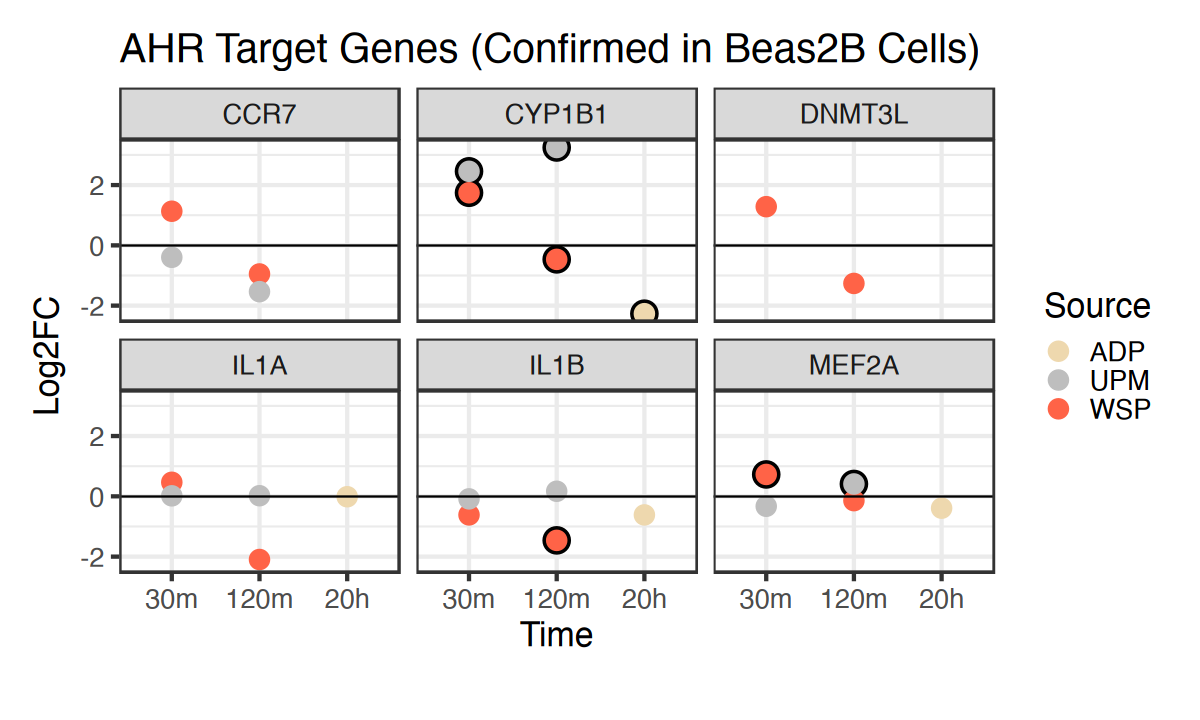

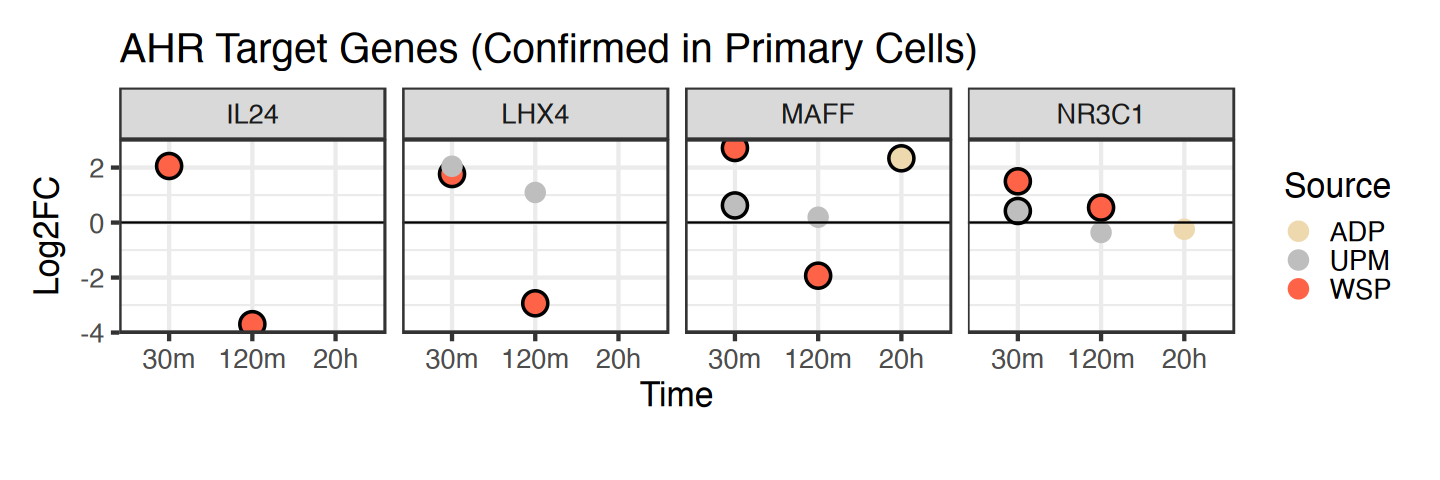

In [375]:
use_genes = c("CYP1B1", "MEF2A", "CCR7", "DNMT3L", "IL1A", "IL1B")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=6, repr.plot.width=10)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("AHR Target Genes (Confirmed in Beas2B Cells)") + facet_wrap(~V1, nrow=2) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p



use_genes = c("LHX4", "IL24", "MAFF", "NR3C1")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=4, repr.plot.width=12)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("AHR Target Genes (Confirmed in Primary Cells)") + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

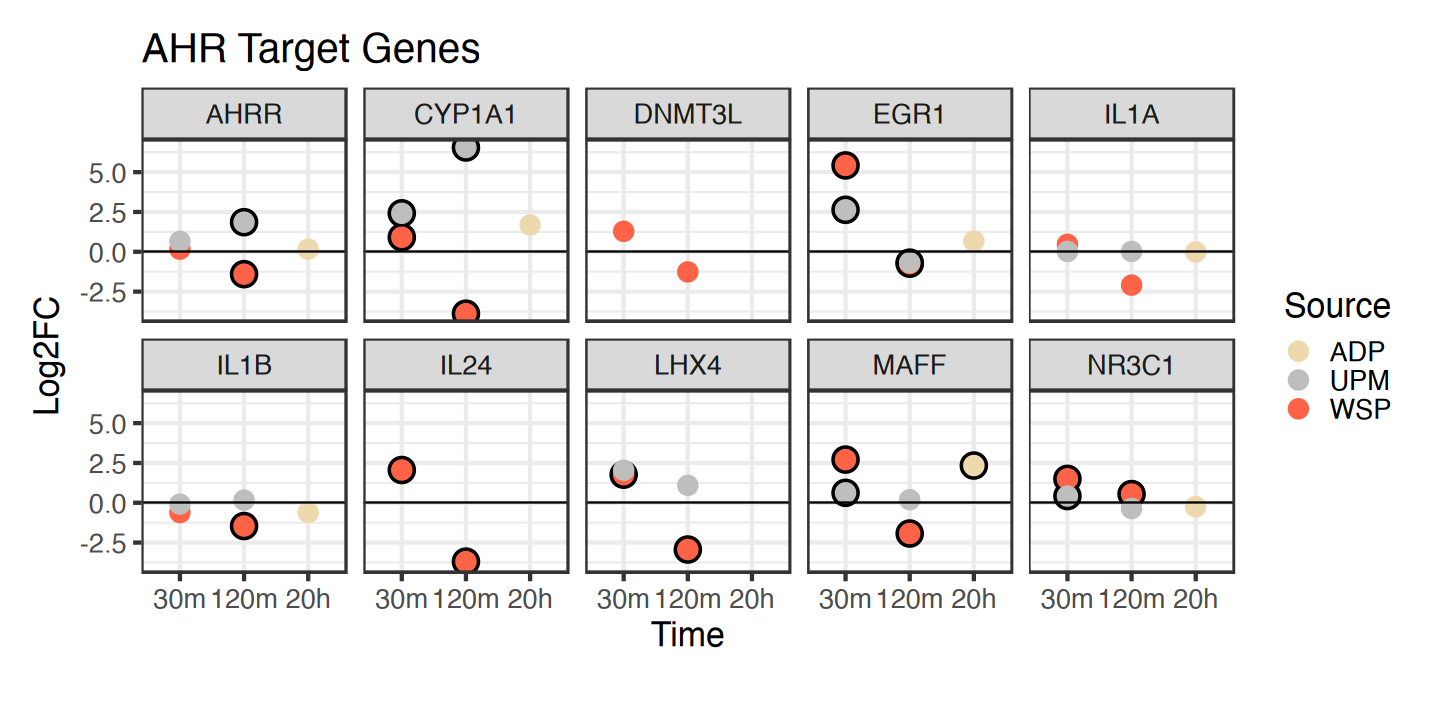

In [368]:
use_genes = c("EGR1", "IL24", "LHX4", "NR3C1", "MAFF", "DNMT3L", 
             "AHRR", "CYP1A1", "IL1A", "IL1B")
plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=6, repr.plot.width=12)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("AHR Target Genes") + facet_wrap(~V1, nrow=2) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

In [45]:
sort(unique(plot_df$V1[grep("CEMIP2", plot_df$V1)]))

[1] "CEMIP2"

In [50]:
use_genes = c("TLR1", "TLR2","TLR3", "TLR4", "TLR5", "TLR6", "TLR9", "TLR10", "HMMR", "TNFAIP6", "STAB2", "PDGFA", 
             "TNF", "IL1B", "PTGS2", "IL6", "IL33", "CXCL8", "IRAK3", "UGDH", "IL10", "MAPK14", "MAPK8", "MAPK9", 
			 "MAPK10", "CEMIP2", "SOX4", "SPAM1")
# HMMR=RHAMM, TNF=TNFA, TNFAIP6=TSG6, HARE=STAB2, COX2=PTGS2, IL8=CXCL8, IRAK-M=IRAK3
#* No clear signal for HAPLN (HYA binding proteins)
setdiff(use_genes, plot_df$V1)

[1] "TNFAIP6"

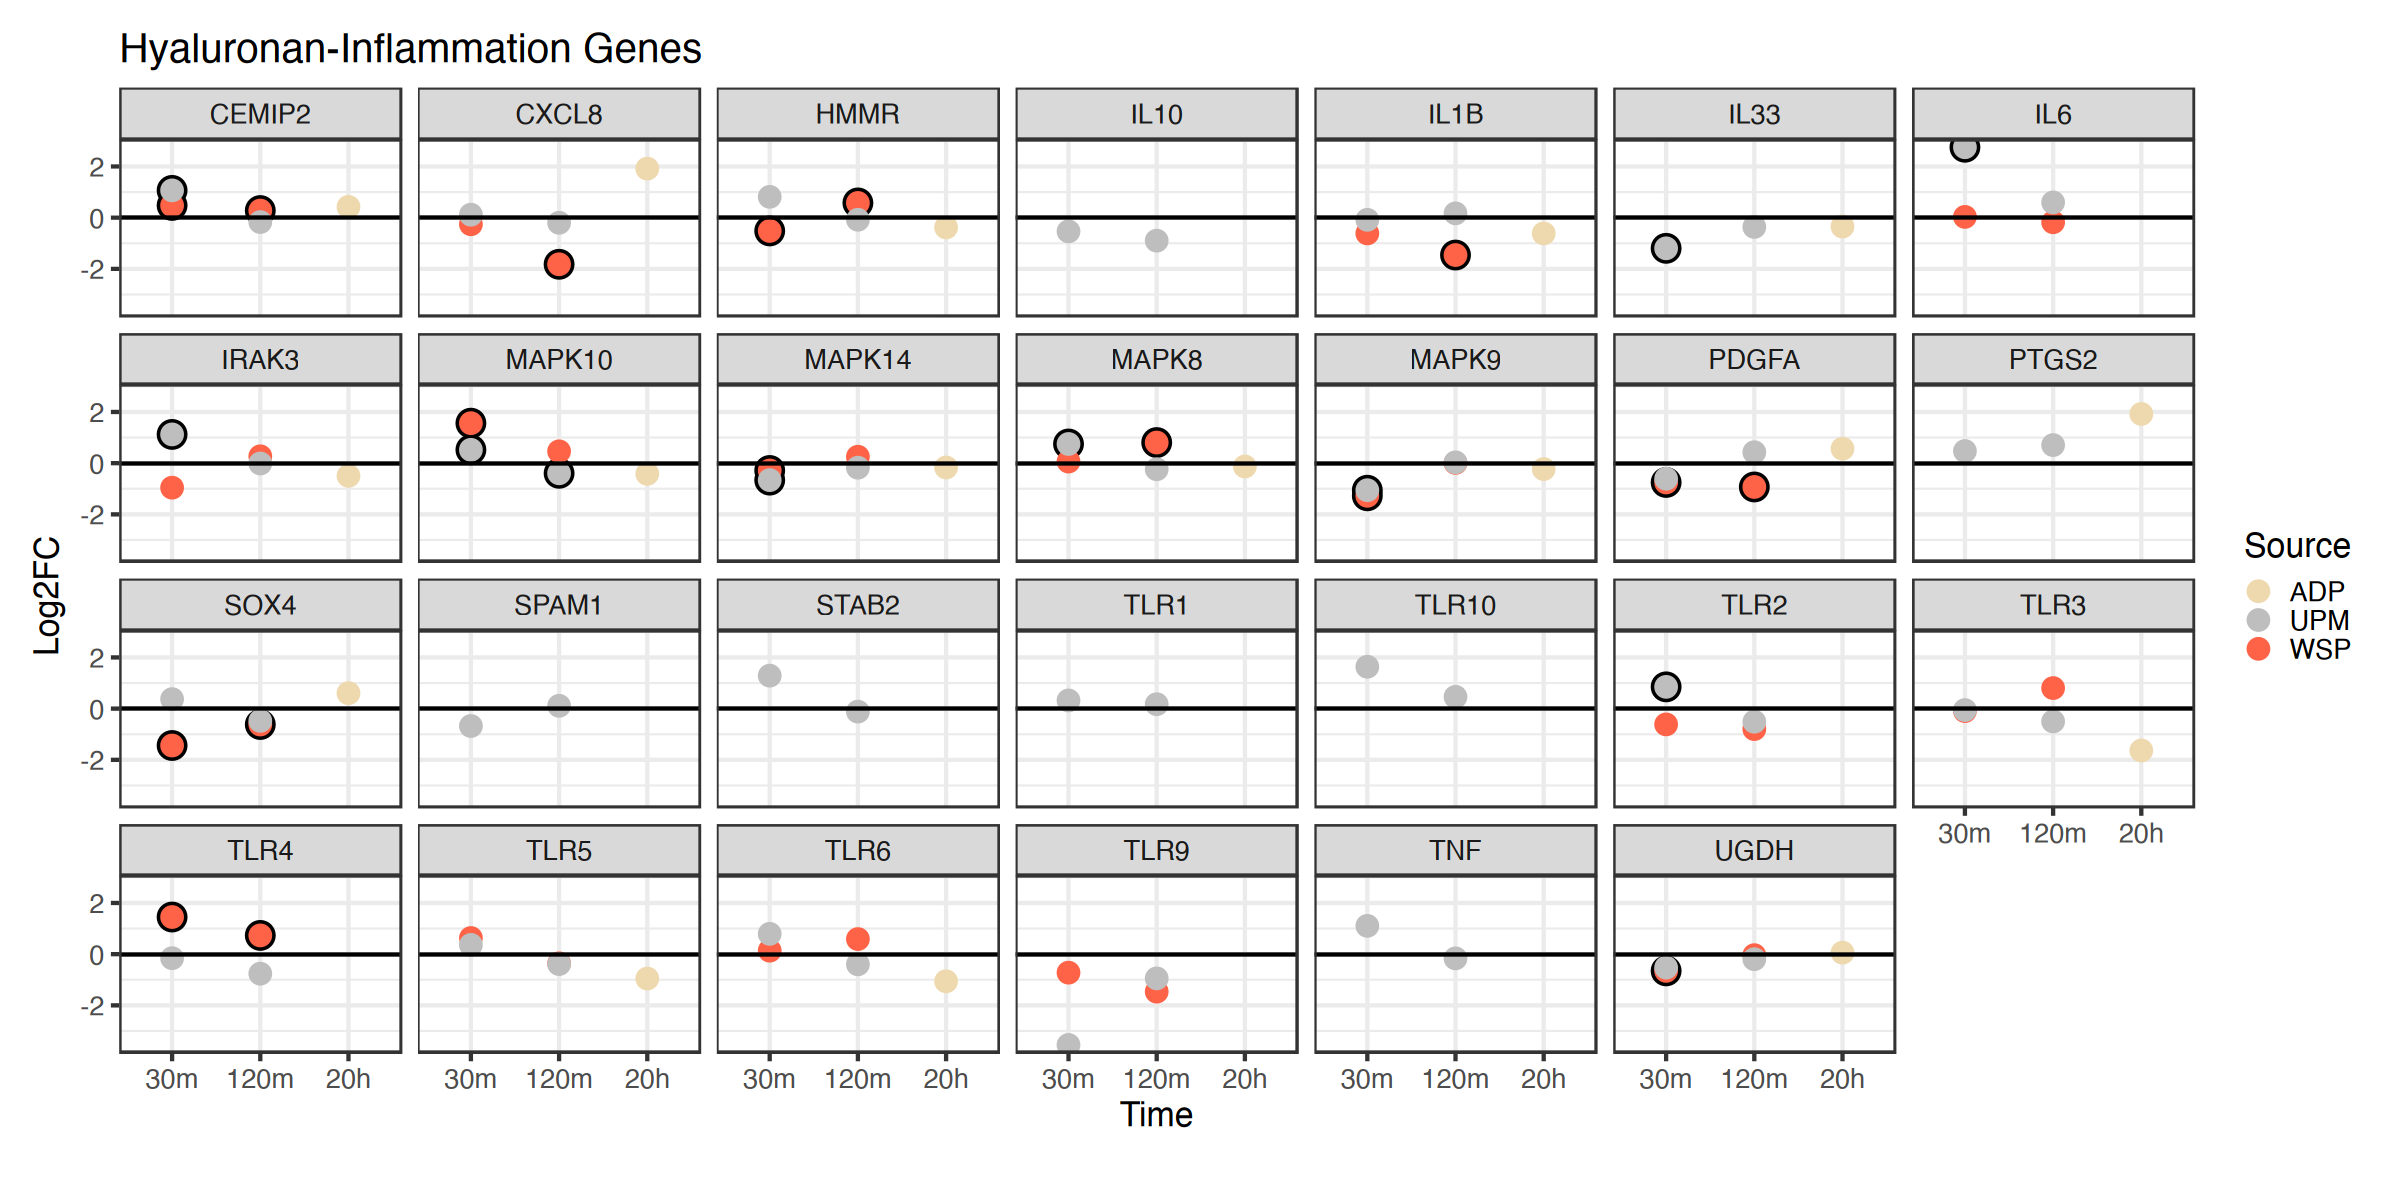

In [51]:

plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))

num_rows = ceiling(length(use_genes)/9)
height_use =10
options(repr.plot.height=height_use, repr.plot.width=20)
p <- ggplot(plot_df_use, 
       aes(x=factor(Time, levels=c("30m", "120m", "20h")), y=log2FoldChange, color=Source)) + 
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("Hyaluronan-Inflammation Genes") + facet_wrap(~V1, nrow=num_rows) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))  # top, right, bottom, left in pts
p

Proinflammatory cytokines: -
* CXCL8 (IL-8) & IL-1B: both very much downregulated in WSP (mostly at 120min)
	* IL-1B helps regulate HA production
* IL10 & IL-33: Down in UPM 30 min and less so at 120 min. Not transcribed in WSP
* IL-6: Up in UPM30 and less so at 120 min
* TNF-A (TNF): Up in UPM30 but not 120 min

p38 (promotes inflrmattory cytokine release) & JNK (phosphorylates AP-1 for pro-apoptotic gene expression)
* MAPK14 (p38) downregulated at 30 min
* MAPK9 (JNK2) downregulated at 30 min
* MAPK8 & MAPK10 (JNK1 and 3) upregulated 

Receptors
* HARE (STAB2) -- how LMW-HA can enter the cell -- upregulated in UPM at 30 min 
* ?RHAMM (HMMR) (microtubule-associated) -- oppositely regulated in WSP and UPM (up UPM and down WSP) at 30 min

Regulation
* PDGF: downregulated in both UPM and WSP 30 min (still for WSP 120min)

Toll like receptors through which LMW are inflammatory
* TLR4 is upregulated in WSP at 30 and 120 min
* TLR9 is downregulated in both (but mostly 30 min for UPM)

UGDH: promote HMW-HA formation -- downregulated at 30 min in both

IRAK-M: upregulated at 30 minutes for UPM, but downregulated for WSP

In [70]:
genes_use = c("CD44", "HYAL1", "HYAL2", "HYAL3", "CEMIP", "CEMIP2", "HAS1", "HAS2", "HAS3",
"TGFB1", "IL6", "TNF", "REL", "TLR2", "UGDH", "UAP1", "PGM3", "GNPNAT1", "GFPT1", "GFPT2",
"PFKP", "PKM", "PC", "PGM1", "PGM2", "LDHA", "ALDOA", "SLC17A5", "FBP1", "UGP2")
setdiff(genes_use, plot_df$V1)


character(0)

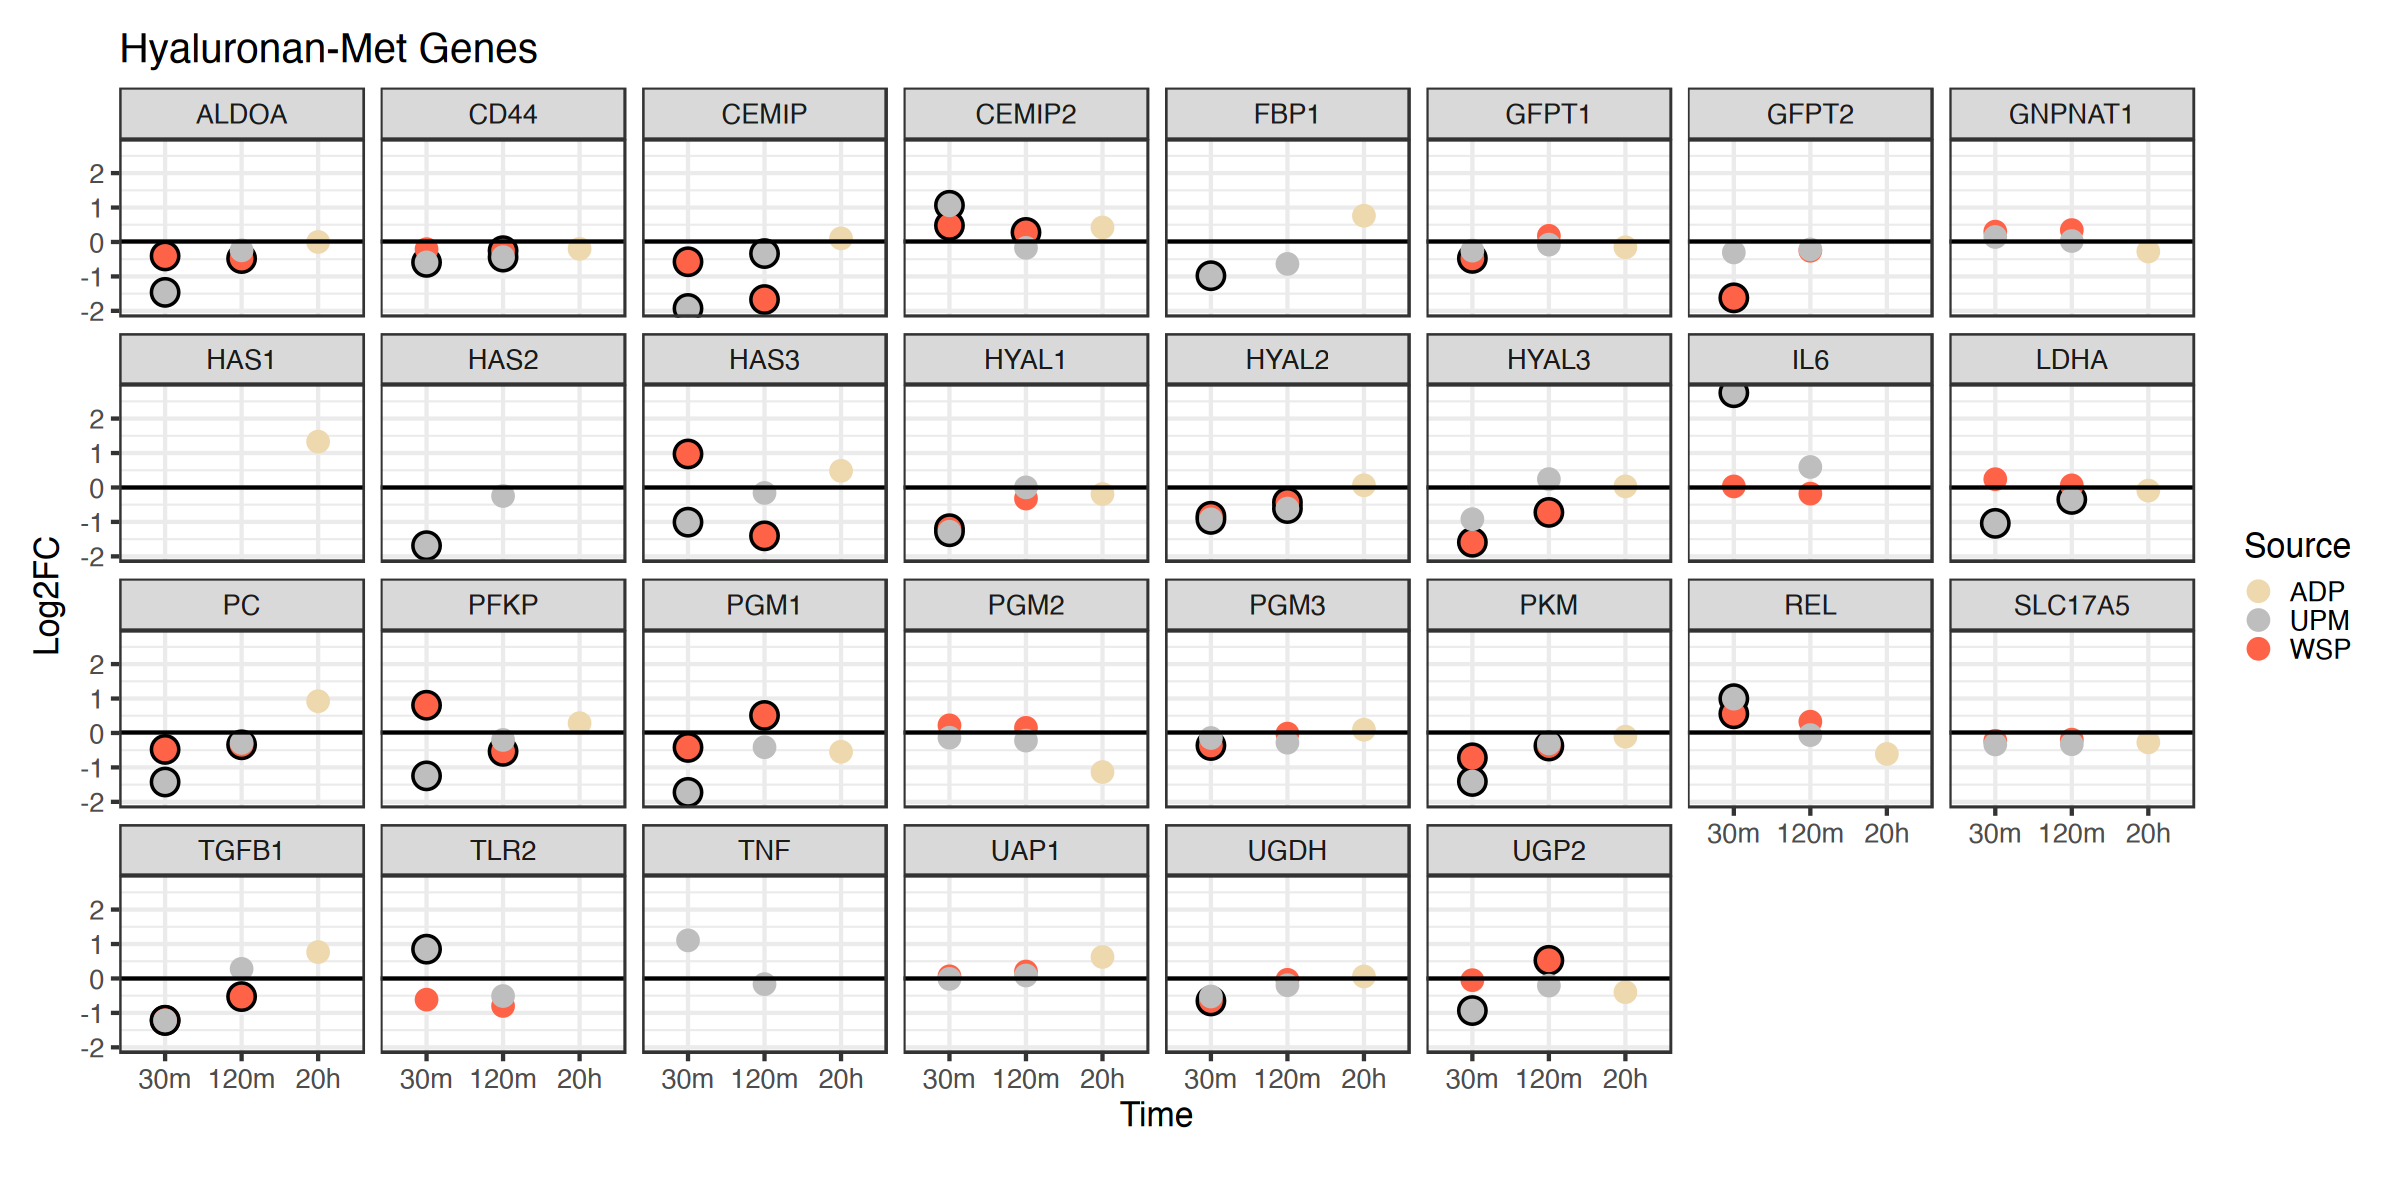

In [71]:

plot_df_use = plot_df[plot_df$V1 %in% genes_use,]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))

num_rows = ceiling(length(genes_use)/9)
height_use =10
options(repr.plot.height=height_use, repr.plot.width=20)
p <- ggplot(plot_df_use, 
       aes(x=factor(Time, levels=c("30m", "120m", "20h")), y=log2FoldChange, color=Source)) + 
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("Hyaluronan-Met Genes") + facet_wrap(~V1, nrow=num_rows) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))  # top, right, bottom, left in pts
p

In [73]:
plot_df_use[1:2,]
unique(plot_df_use$Source_Time)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Source,Time,Sig,Source_Time
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>
PC,4780.4271,0.9214131,0.3575901,2.576730,0.009973995,0.09792915,ADP,20h,NonSig,ADP_20h
TGFB1,760.3093,0.7666029,0.3180630,2.410223,0.015942757,0.13273309,ADP,20h,NonSig,ADP_20h


[1] "ADP_20h"  "WSP_120m" "WSP_30m"  "UPM_120m" "UPM_30m"

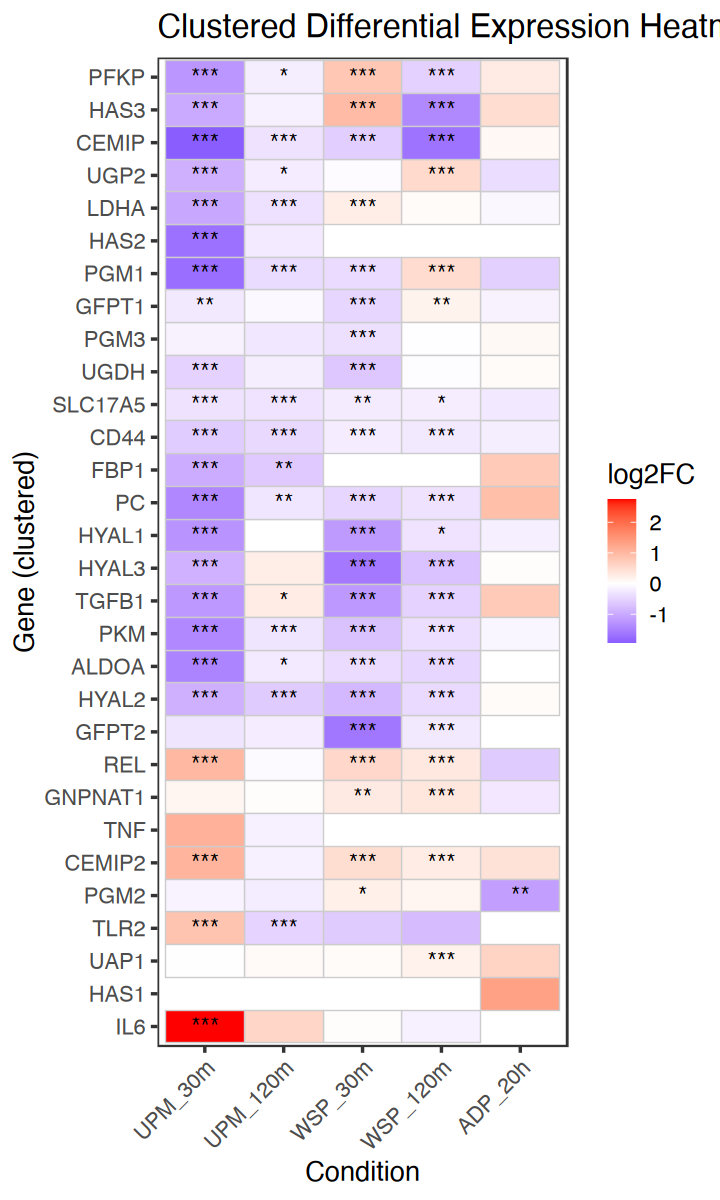

In [80]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(cluster)

# ---- 1. Define order of columns ----
time_order <- c("UPM_30m", "UPM_120m", "WSP_30m", "WSP_120m", "ADP_20h")

# ---- 2. Prepare dataframe: significance labels ----
plot_df <- plot_df_use %>%
  mutate(
    Source_Time = factor(Source_Time, levels = time_order),
    sig = case_when(
      padj < 0.001 ~ "***",
      padj < 0.01  ~ "**",
      padj < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

# ---- 3. Pivot to wide to compute clustering ----
mat <- plot_df %>%
  select(V1, Source_Time, log2FoldChange) %>%
  pivot_wider(names_from = Source_Time, values_from = log2FoldChange) %>%
  tibble::column_to_rownames("V1")

# ---- 4. Hierarchical clustering on rows ----
# (Use pairwise-complete to allow NA)
#install.packages("proxy")   # if not installed
#library(proxy)

# compute pairwise-complete distance matrix
mat_cluster <- mat
mat_cluster[is.na(mat_cluster)] <- 0
dist_rows <- dist(mat_cluster, metric = "euclidean")

clust_rows <- hclust(dist_rows, method = "average")
gene_order <- clust_rows$labels[clust_rows$order]


# Get gene order from clustering
gene_order <- clust_rows$labels[clust_rows$order]

# ---- 5. Back to long format with clustered row order ----
plot_df <- plot_df %>%
  mutate(V1 = factor(V1, levels = gene_order))

# ---- 6. Plot with NA as grey ----
ggplot(plot_df, aes(x = Source_Time, y = V1, fill = log2FoldChange)) +
  geom_tile(color = "grey80") +
  
  # significance asterisks
  geom_text(aes(label = sig), size = 5, color = "black") +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0,
    na.value = "grey80",
    name = "log2FC"
  ) +
  
  theme_bw(base_size = 16) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  ) +
  
  labs(
    x = "Condition",
    y = "Gene (clustered)",
    title = "Clustered Differential Expression Heatmap"
  )


library(cluster)

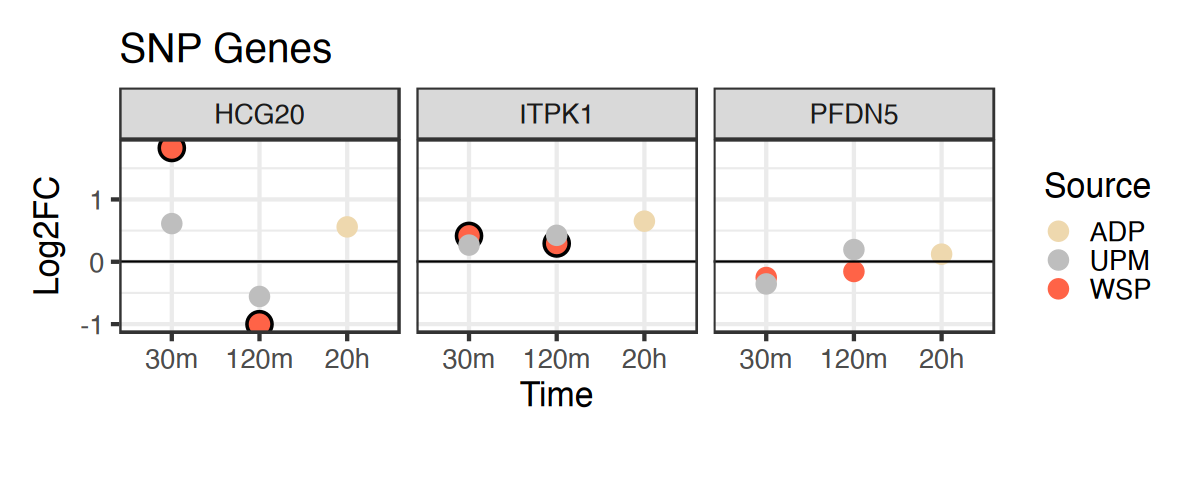

In [21]:

plot_df_use = plot_df[plot_df$V1 %in% c("ITPK1", "HCG20", "PFDN5"),]
plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
options(repr.plot.height=4, repr.plot.width=10)
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle("SNP Genes") + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))
p

### Plotting Normalized Counts

In [15]:
rna_counts_wsp[1:2,]

Veh_1,Veh_2,Veh_3,Veh_4,WSP2h_1,WSP2h_2,WSP2h_3,WSP2h_4,WSP4h_1,WSP4h_2,WSP4h_3,WSP4h_4,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.000,0.000,0.0000,0.9599782,0.000,0.0000,0.0000,1.874102,0.0000,0.0000,0.0000,0.0000,DDX11L1
105.856,109.665,106.0417,119.9972757,106.535,158.4451,120.8592,124.627788,145.5898,148.4347,130.7618,128.7125,WASH7P


In [21]:
# read in the counts
counts_upm <- fread("../results/DESeq2/UPM_normalized_counts.txt")
counts_upm[1:2,]
counts_wsp <- fread("../results/DESeq2/WSP_normalized_counts.txt")
counts_wsp[1:2,]

counts_adp <- fread("../results/DESeq2/ADP_normalized_counts.txt")
counts_adp[1:2,]

rna_counts_wsp <- fread("../results/DESeq2/WSP_RNAseq_normalized_counts.txt")

# Convert wide to long
counts_upm_long <- counts_upm %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("UPM120", Sample) ~ "120",
      grepl("UPM30", Sample) ~ "30",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

counts_wsp_long <- counts_wsp %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("WSP120", Sample) ~ "120",
      grepl("WSP30", Sample) ~ "30",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

counts_adp_long <- counts_adp %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("ADP", Sample) ~ "20h",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

rna_counts_wsp_long <- rna_counts_wsp %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("WSP2h", Sample) ~ "2h",
      grepl("WSP4h", Sample) ~ "4h",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

# Optional: factor levels for ordered time
counts_upm_long$Time <- factor(counts_upm_long$Time, levels = c("0", "30", "120", "20h"))
counts_wsp_long$Time <- factor(counts_wsp_long$Time, levels = c("0", "30", "120", "20h"))
counts_adp_long$Time <- factor(counts_adp_long$Time, levels = c("0", "30", "120", "20h"))
rna_counts_wsp_long$Time <- factor(rna_counts_wsp_long$Time, levels = c("0", "2h", "4h"))

counts_upm_long[1:2,]
counts_wsp_long[1:2,]

counts_upm_long$Source <- "UPM"
counts_wsp_long$Source <- "WSP"
rna_counts_wsp_long$Source <- "WSP"
counts_adp_long$Source <- "ADP"
counts_long <- rbind(counts_upm_long, counts_wsp_long)
counts_long <- rbind(counts_long, counts_adp_long)
counts_long$Group <- paste0(counts_long$Replicate, "_", counts_long$Source)
rna_counts_wsp_long$Group <- paste0(rna_counts_wsp_long$Replicate, "_", rna_counts_wsp_long$Source)
counts_long[1:2,]



UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1668.91368,1889.97076,701.9595,972.6107,1437.0427,1506.9871,FAM24B-CUZD1
80.66715,36.12724,289.8334,223.7285,115.2814,82.0129,LINC01483


Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3850.338,4054.513,2363.610,2347.456,3541.10,3308.52,PLK1
8158.620,7672.226,7631.873,7651.813,11116.92,12218.49,COP1


ADP_1,ADP_2,Veh_1,Veh_2,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.000,1.851985,2.412154,12.07864,MAP1A
2175.825,1381.580500,1992.438995,1561.76817,H3-3B


Gene,Sample,Count,Time,Replicate
<chr>,<chr>,<dbl>,<fct>,<chr>
FAM24B-CUZD1,UPM120_1,1668.914,120,Rep1
FAM24B-CUZD1,UPM120_2,1889.971,120,Rep2


Gene,Sample,Count,Time,Replicate
<chr>,<chr>,<dbl>,<fct>,<chr>
PLK1,Veh_1,3850.338,0,Rep1
PLK1,Veh_2,4054.513,0,Rep2


Gene,Sample,Count,Time,Replicate,Source,Group
<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<chr>
FAM24B-CUZD1,UPM120_1,1668.914,120,Rep1,UPM,Rep1_UPM
FAM24B-CUZD1,UPM120_2,1889.971,120,Rep2,UPM,Rep2_UPM


In [12]:
counts_upm_scaled <- counts_upm_long %>%
  group_by(Gene) %>%
  mutate(
    Scaled = (Count - min(Count)) / (max(Count) - min(Count))
  ) %>%
  ungroup()

counts_wsp_scaled <- counts_wsp_long %>%
  group_by(Gene) %>%
  mutate(
    Scaled = (Count - min(Count)) / (max(Count) - min(Count))
  ) %>%
  ungroup()

counts_adp_scaled <- counts_adp_long %>%
  group_by(Gene) %>%
  mutate(
    Scaled = (Count - min(Count)) / (max(Count) - min(Count))
  ) %>%
  ungroup()

counts_upm_scaled$Source <- "UPM"
counts_wsp_scaled$Source <- "WSP"
counts_adp_scaled$Source <- "ADP"
counts_scaled_long <- rbind(counts_upm_scaled, counts_wsp_scaled)
counts_scaled_long <- rbind(counts_scaled_long, counts_adp_scaled)
counts_scaled_long$Group <- paste0(counts_scaled_long$Replicate, "_", counts_scaled_long$Source)
counts_scaled_long[1:2,]

Gene,Sample,Count,Time,Replicate,Source,Scaled,Group
<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<chr>
FAM24B-CUZD1,UPM120_1,1668.914,120,Rep1,UPM,0.8139268,Rep1_UPM
FAM24B-CUZD1,UPM120_2,1889.971,120,Rep2,UPM,1.0000000,Rep2_UPM


In [12]:
#plot_long

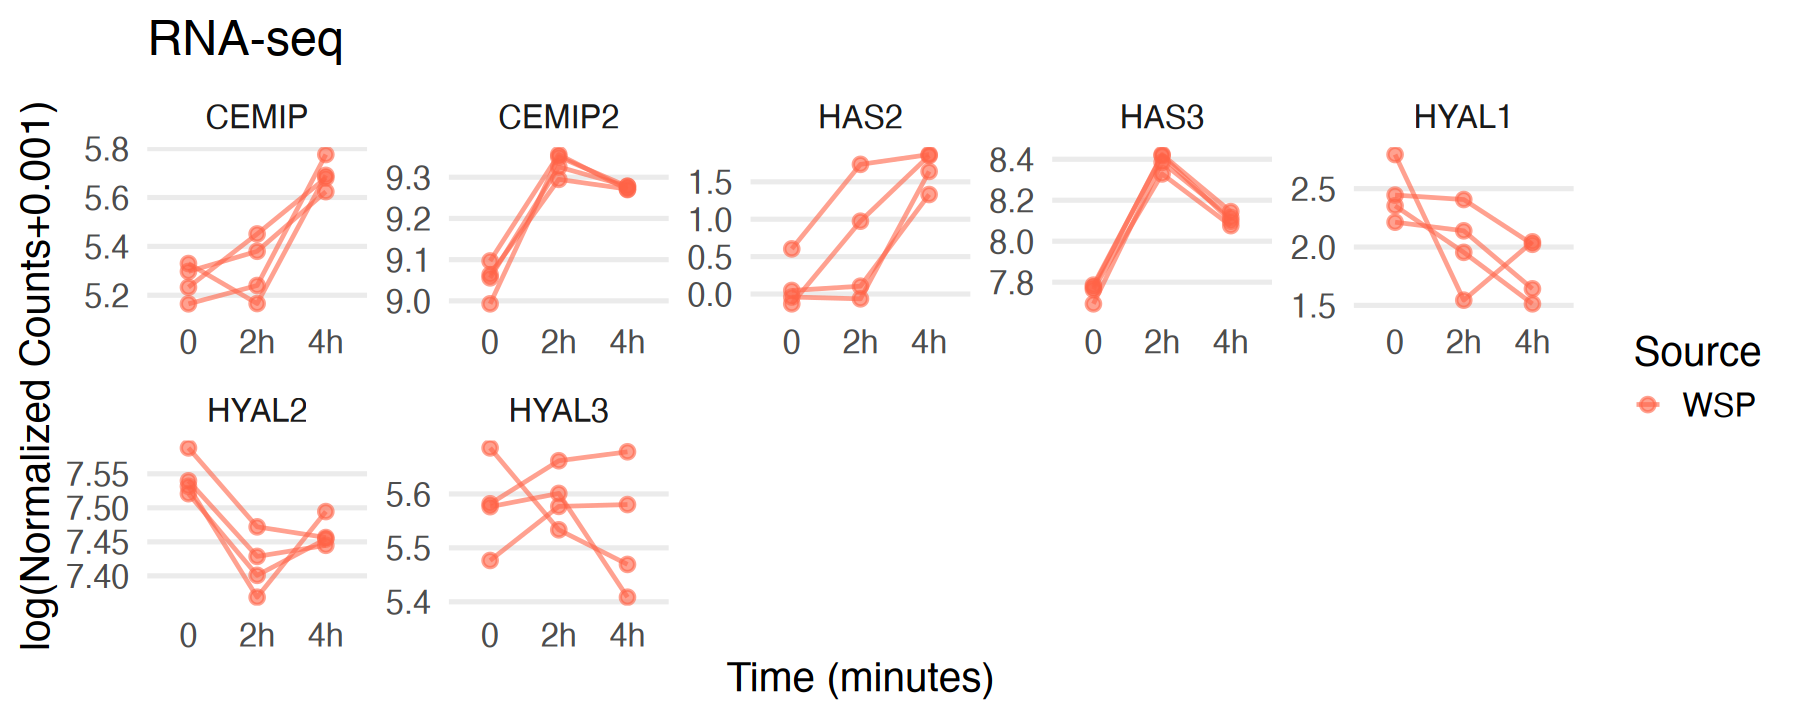

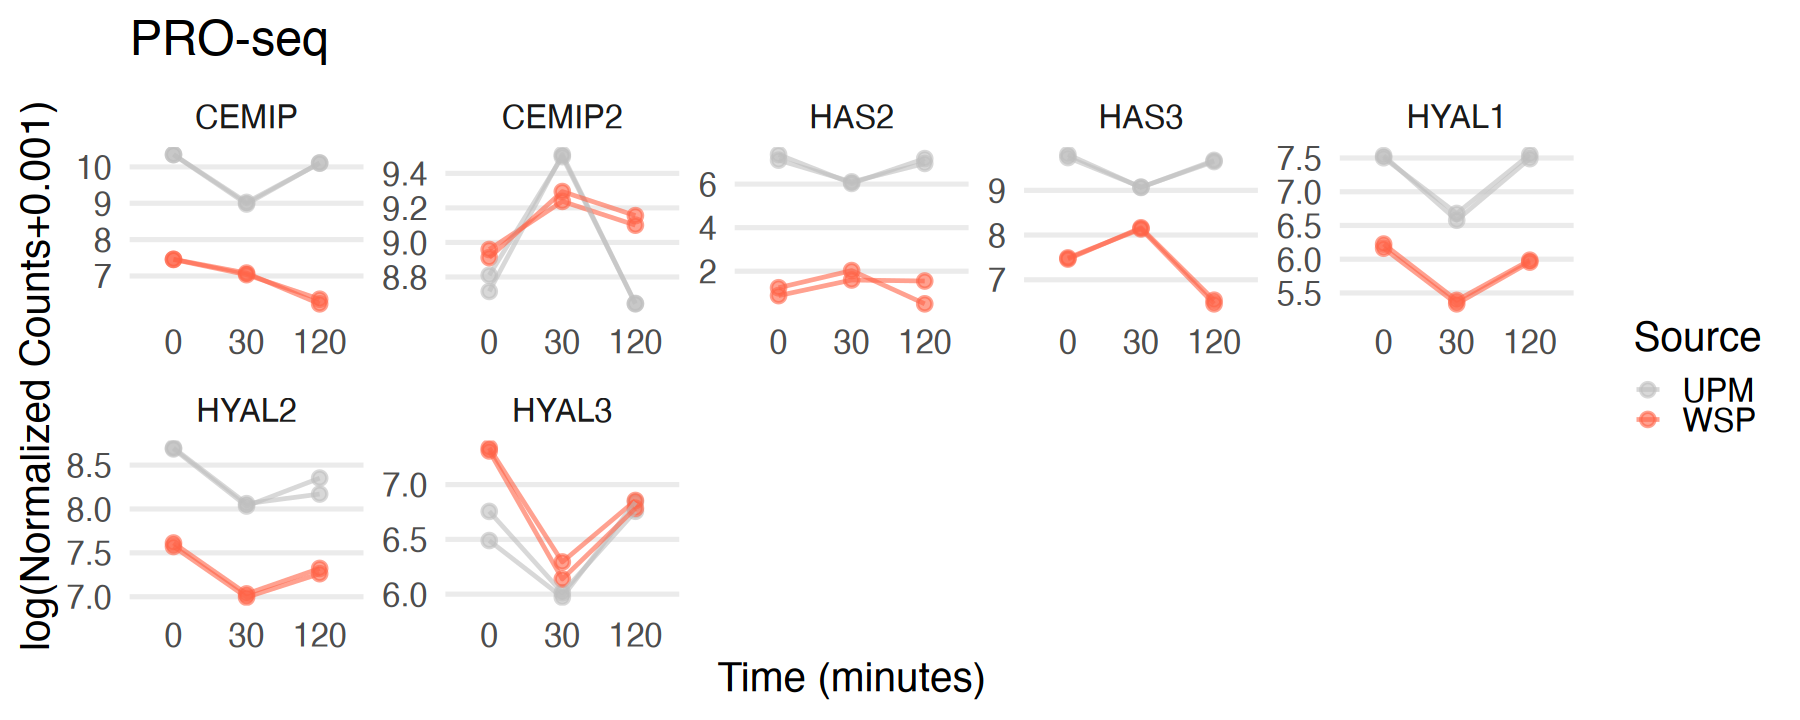

In [27]:
hyal_genes = c("HAS2", "HAS3", "HYAL1", "HYAL2", "HYAL3", "CEMIP", "CEMIP2")
plot_long = rna_counts_wsp_long[rna_counts_wsp_long$Gene %in% hyal_genes,]

color_map = c("ADP"="wheat2", "WSP"="tomato", "UPM"="grey")
options(repr.plot.width=15, repr.plot.height=6)
ggplot(plot_long, aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free", ncol=5) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "RNA-seq", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

plot_long = counts_long[counts_long$Gene %in% hyal_genes & counts_long$Source != "ADP",]
ggplot(plot_long, aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free", ncol=5) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "PRO-seq", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

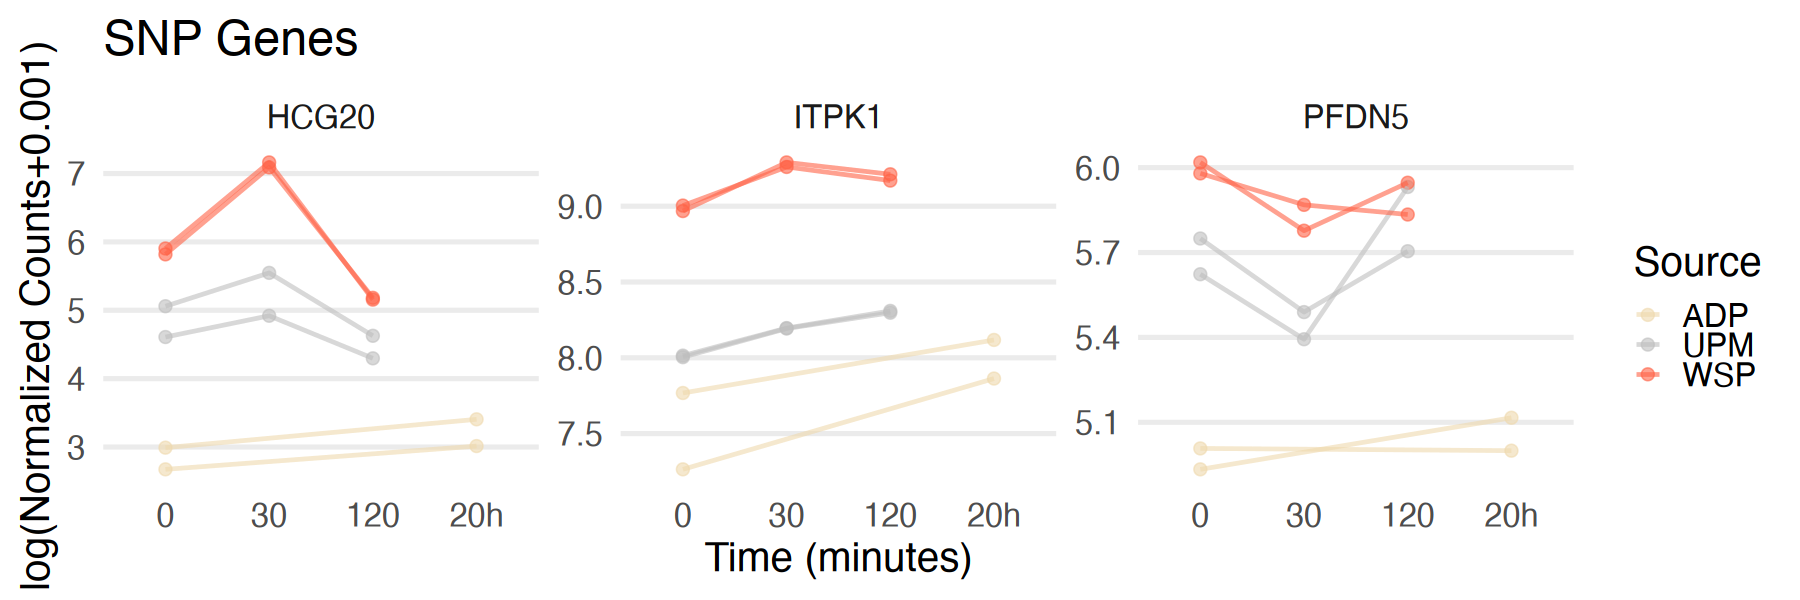

In [15]:
options(repr.plot.width=15, repr.plot.height=5)

#use_genes = c("AHRR")
counts_scaled_long_plot = counts_scaled_long[counts_scaled_long$Gene %in% c("ITPK1", "HCG20", "PFDN5"),]
ggplot(counts_scaled_long_plot, aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free", ncol=5) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "SNP Genes", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

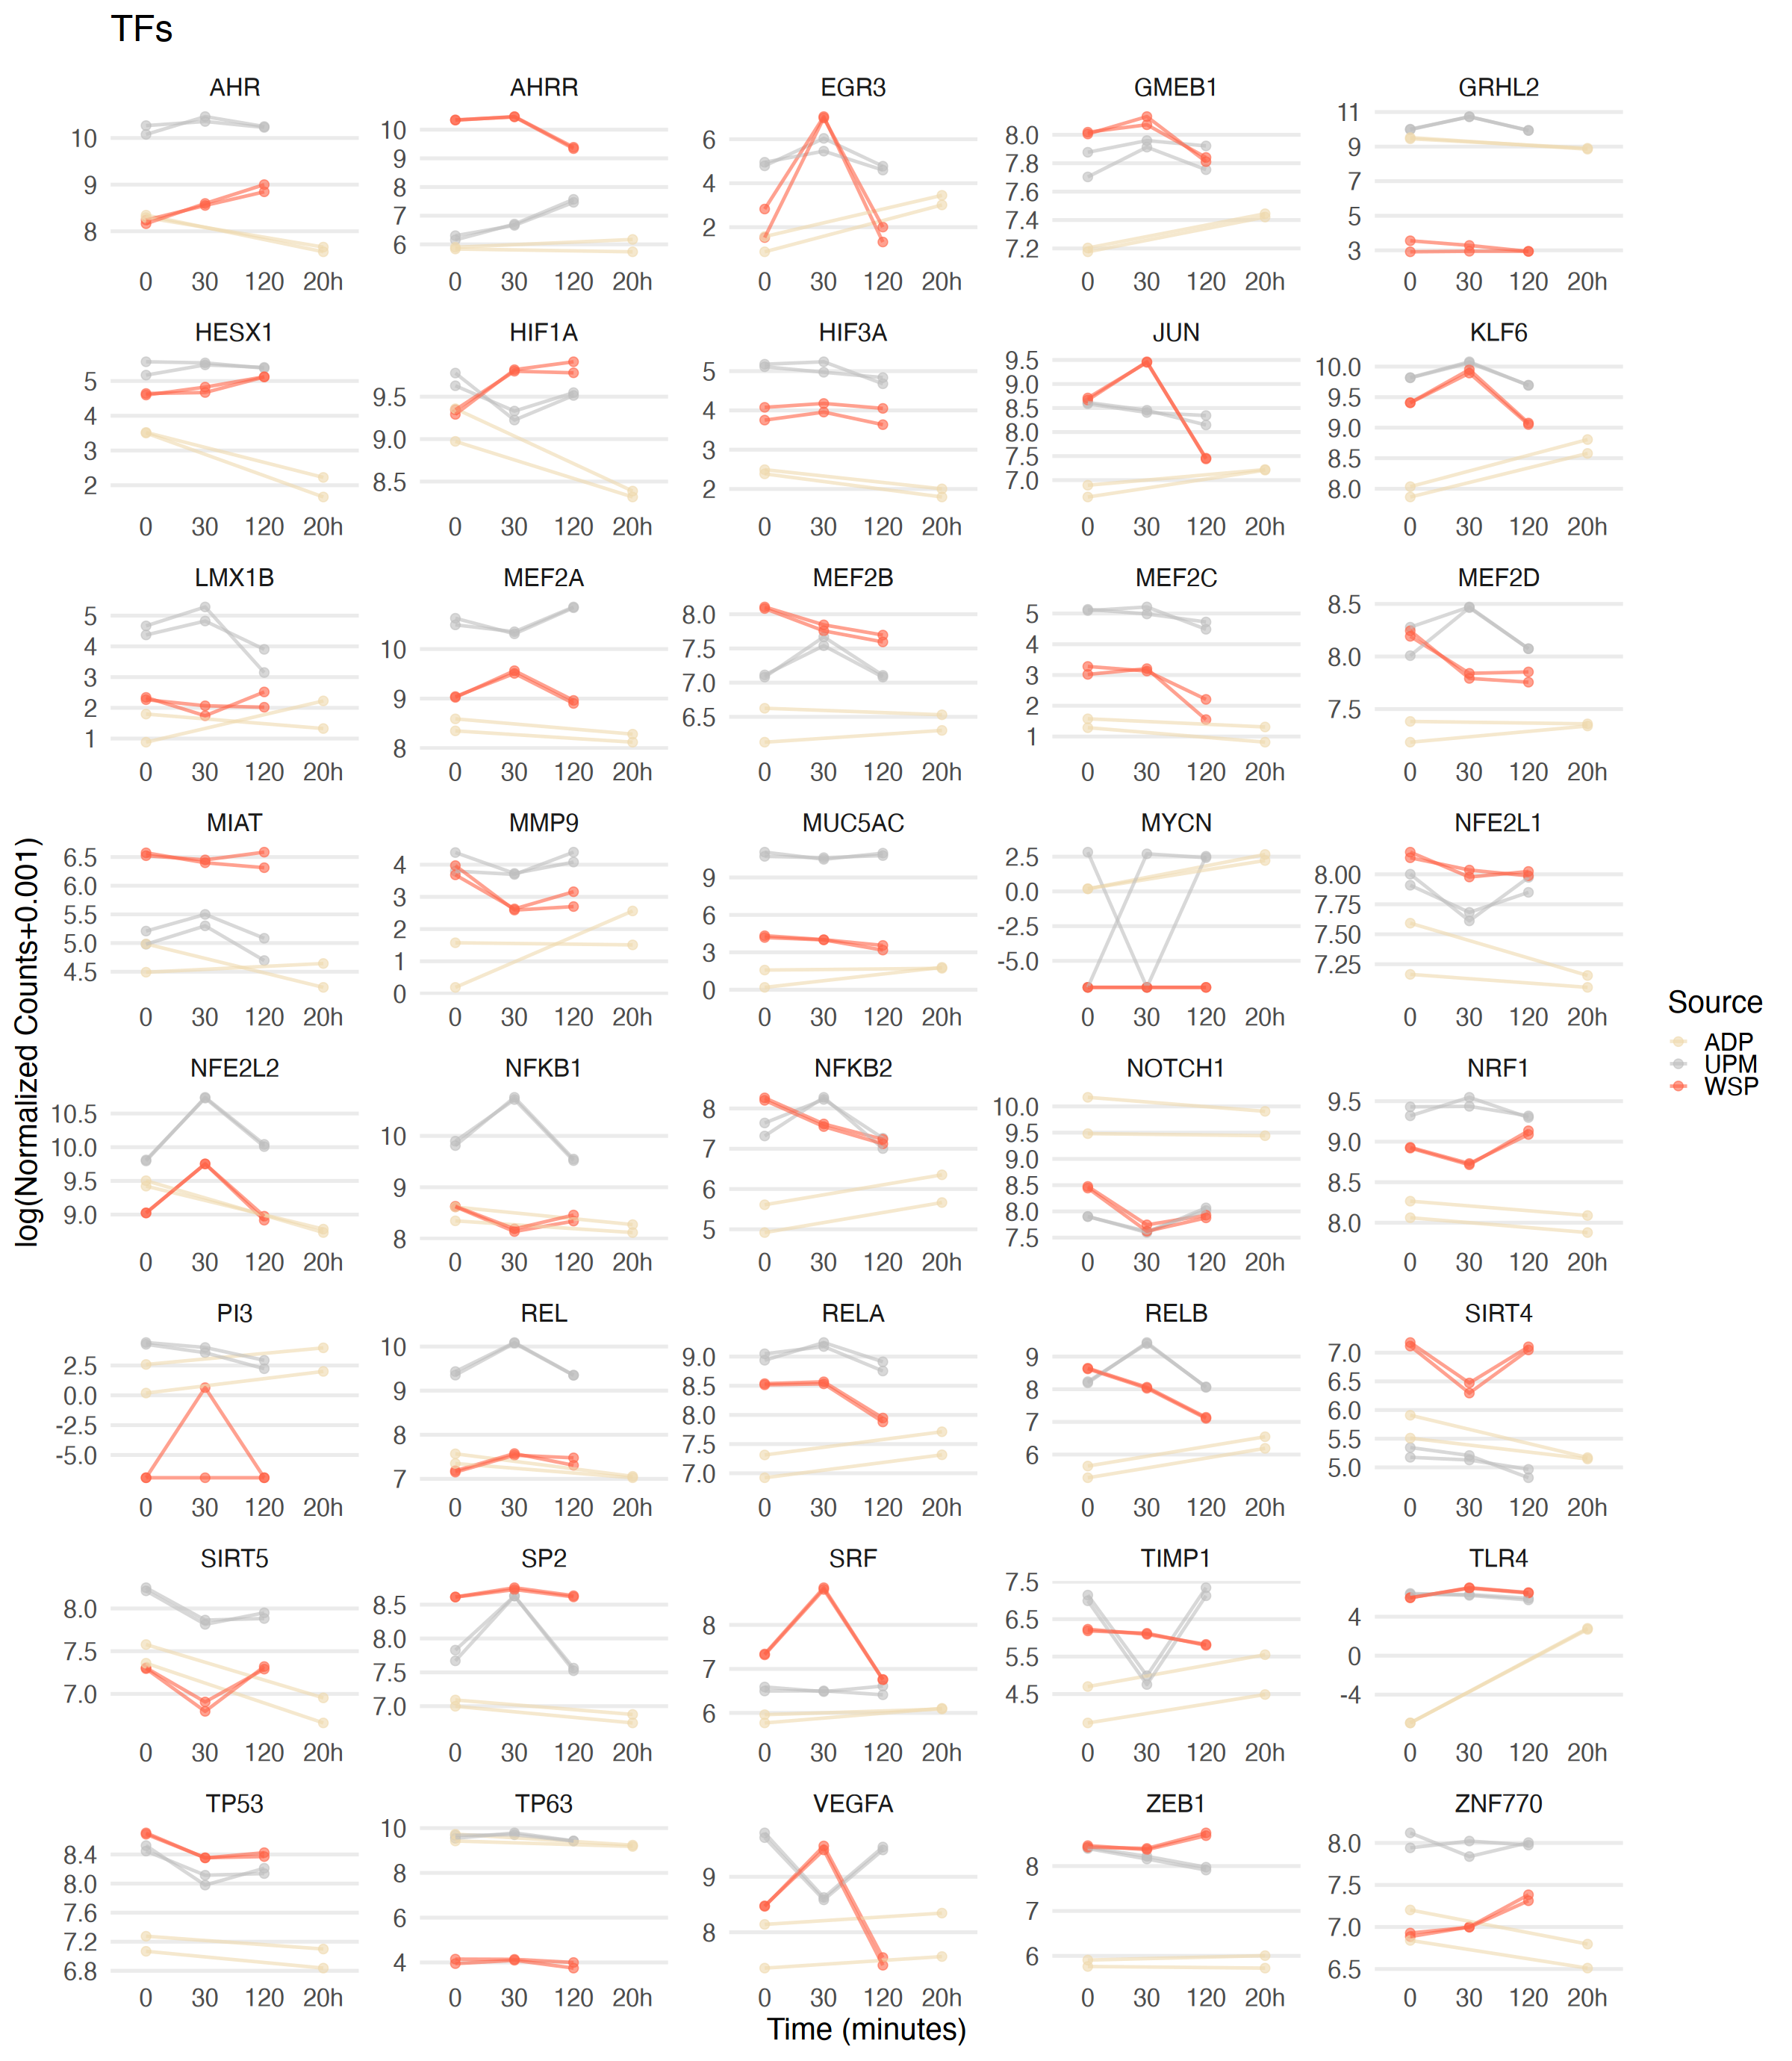

In [82]:
options(repr.plot.width=20, repr.plot.height=15)

#use_genes = c("AHRR")
counts_scaled_long_plot = counts_scaled_long[counts_scaled_long$Gene %in% c(tf_genes, "EGR3", "SRF", "SP2"),]
options(repr.plot.width=20, repr.plot.height=23)
ggplot(counts_scaled_long_plot, aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free", ncol=5) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


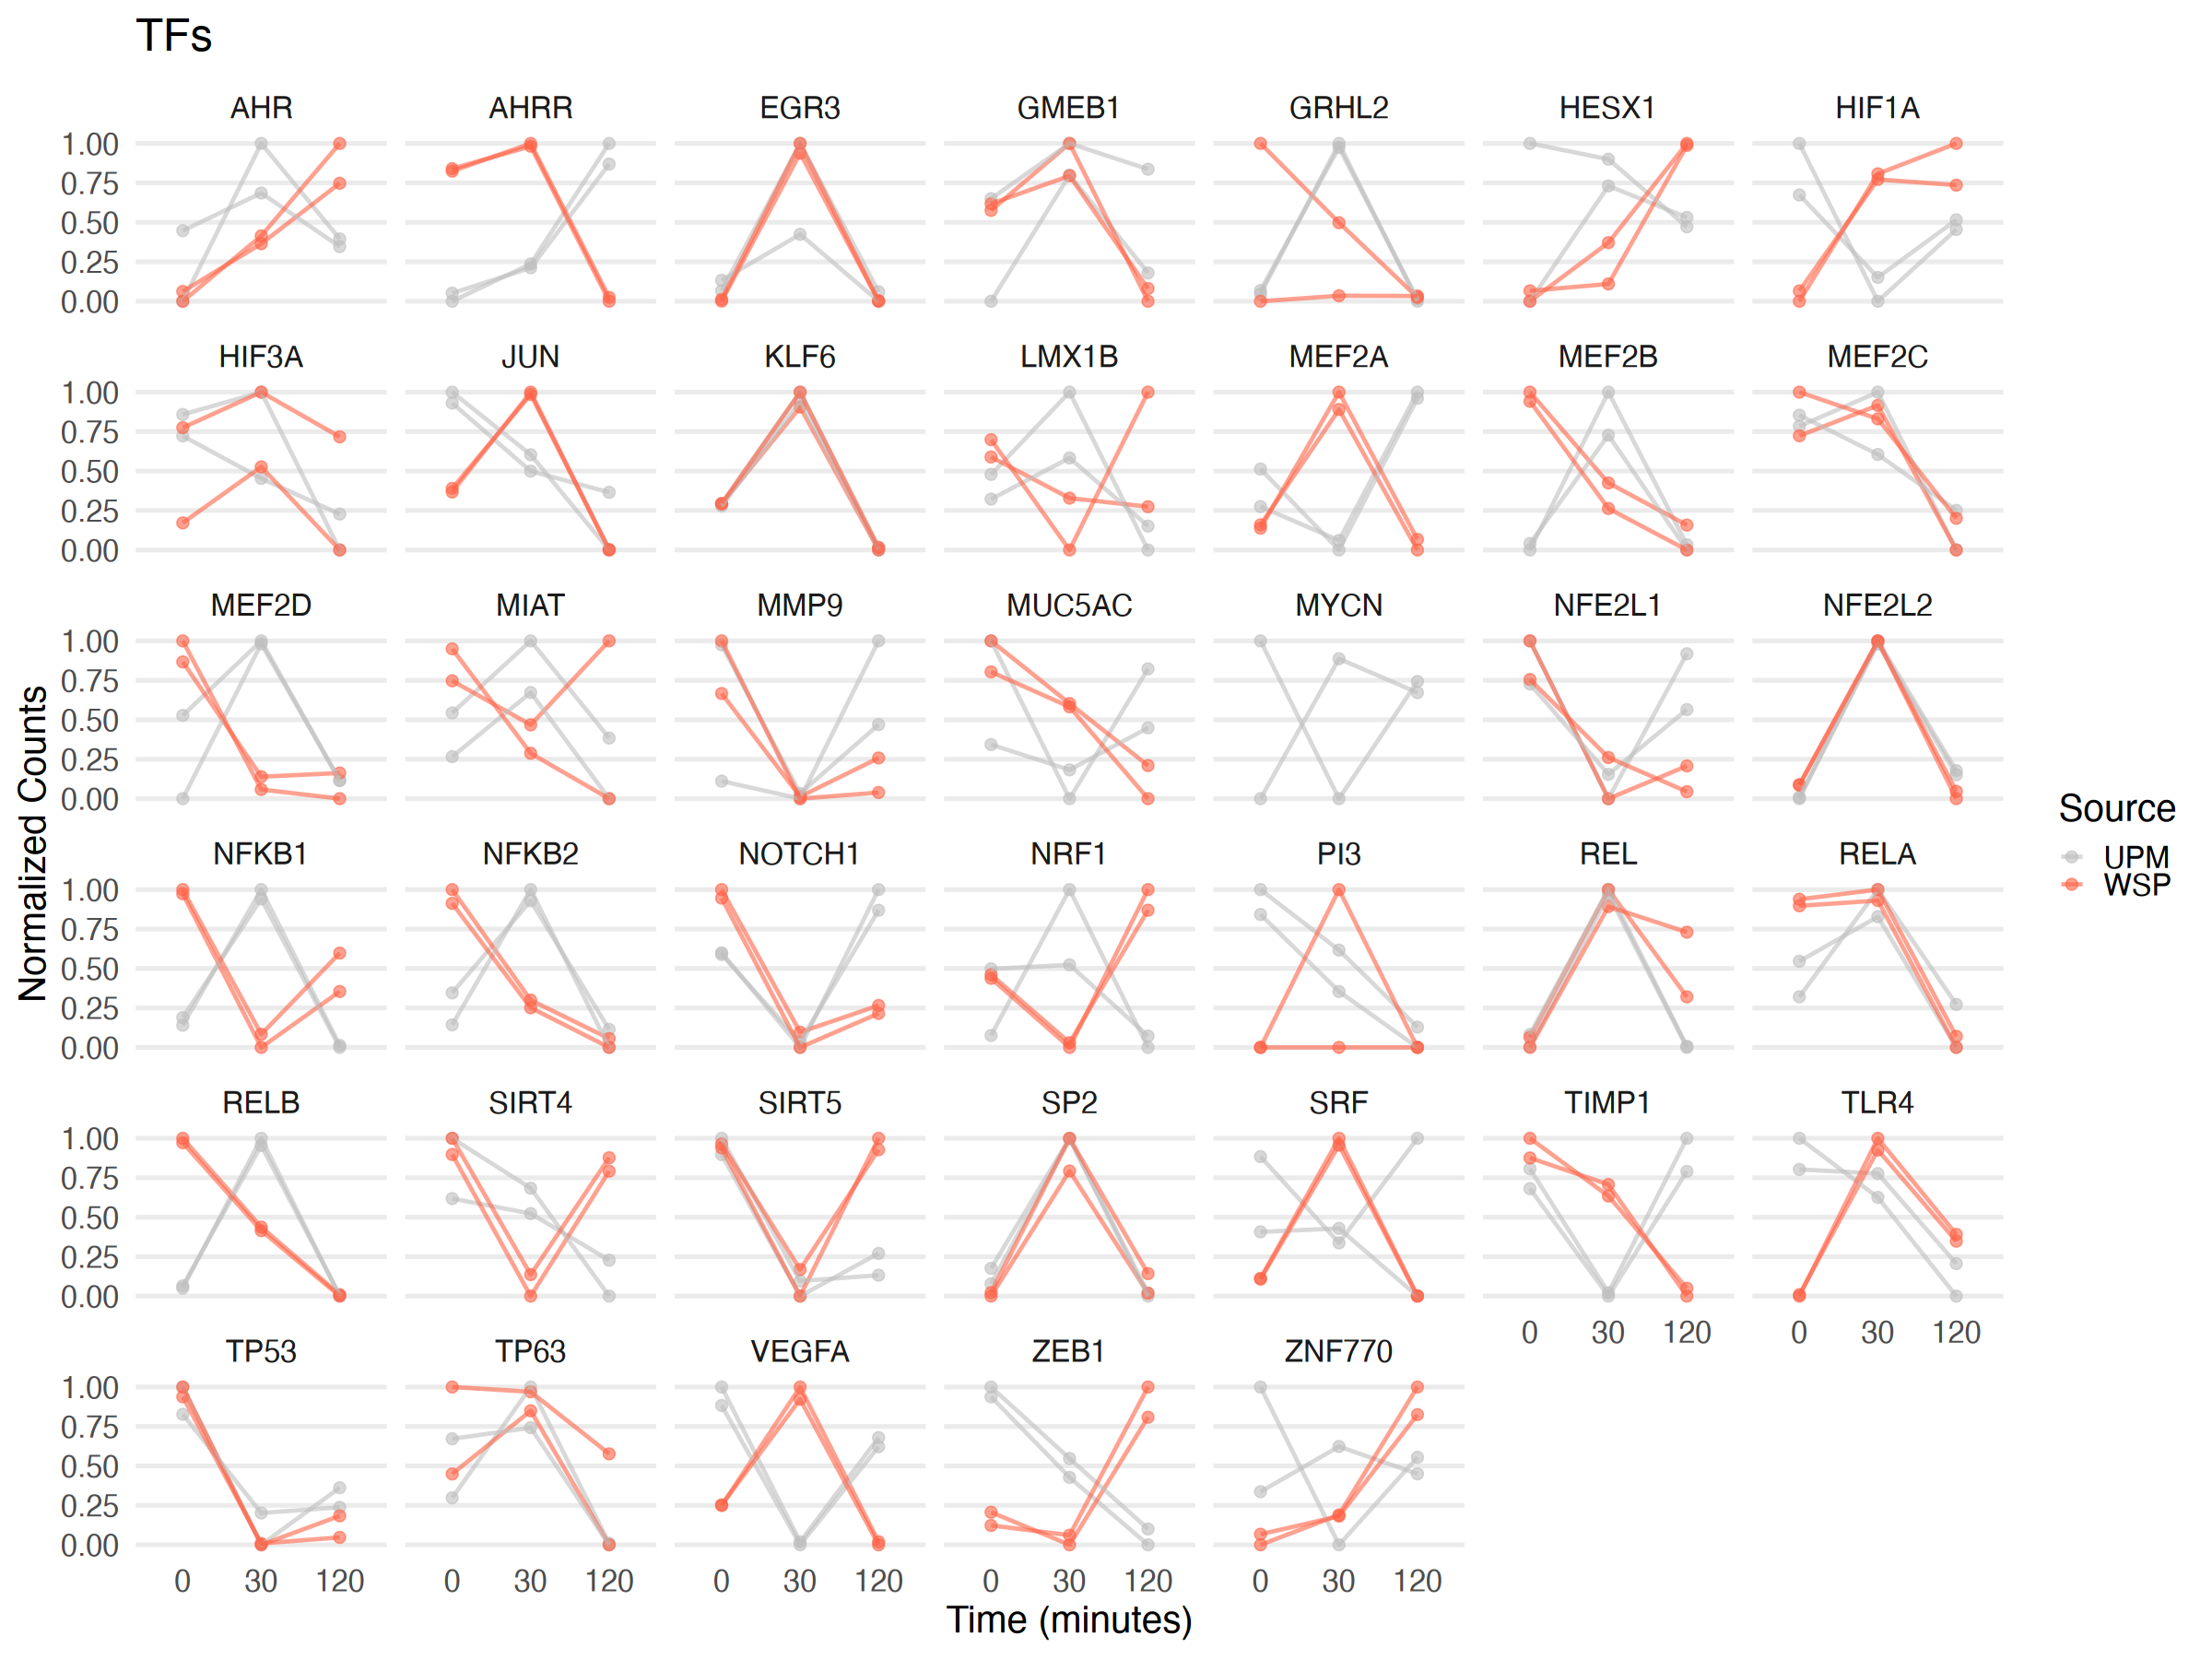

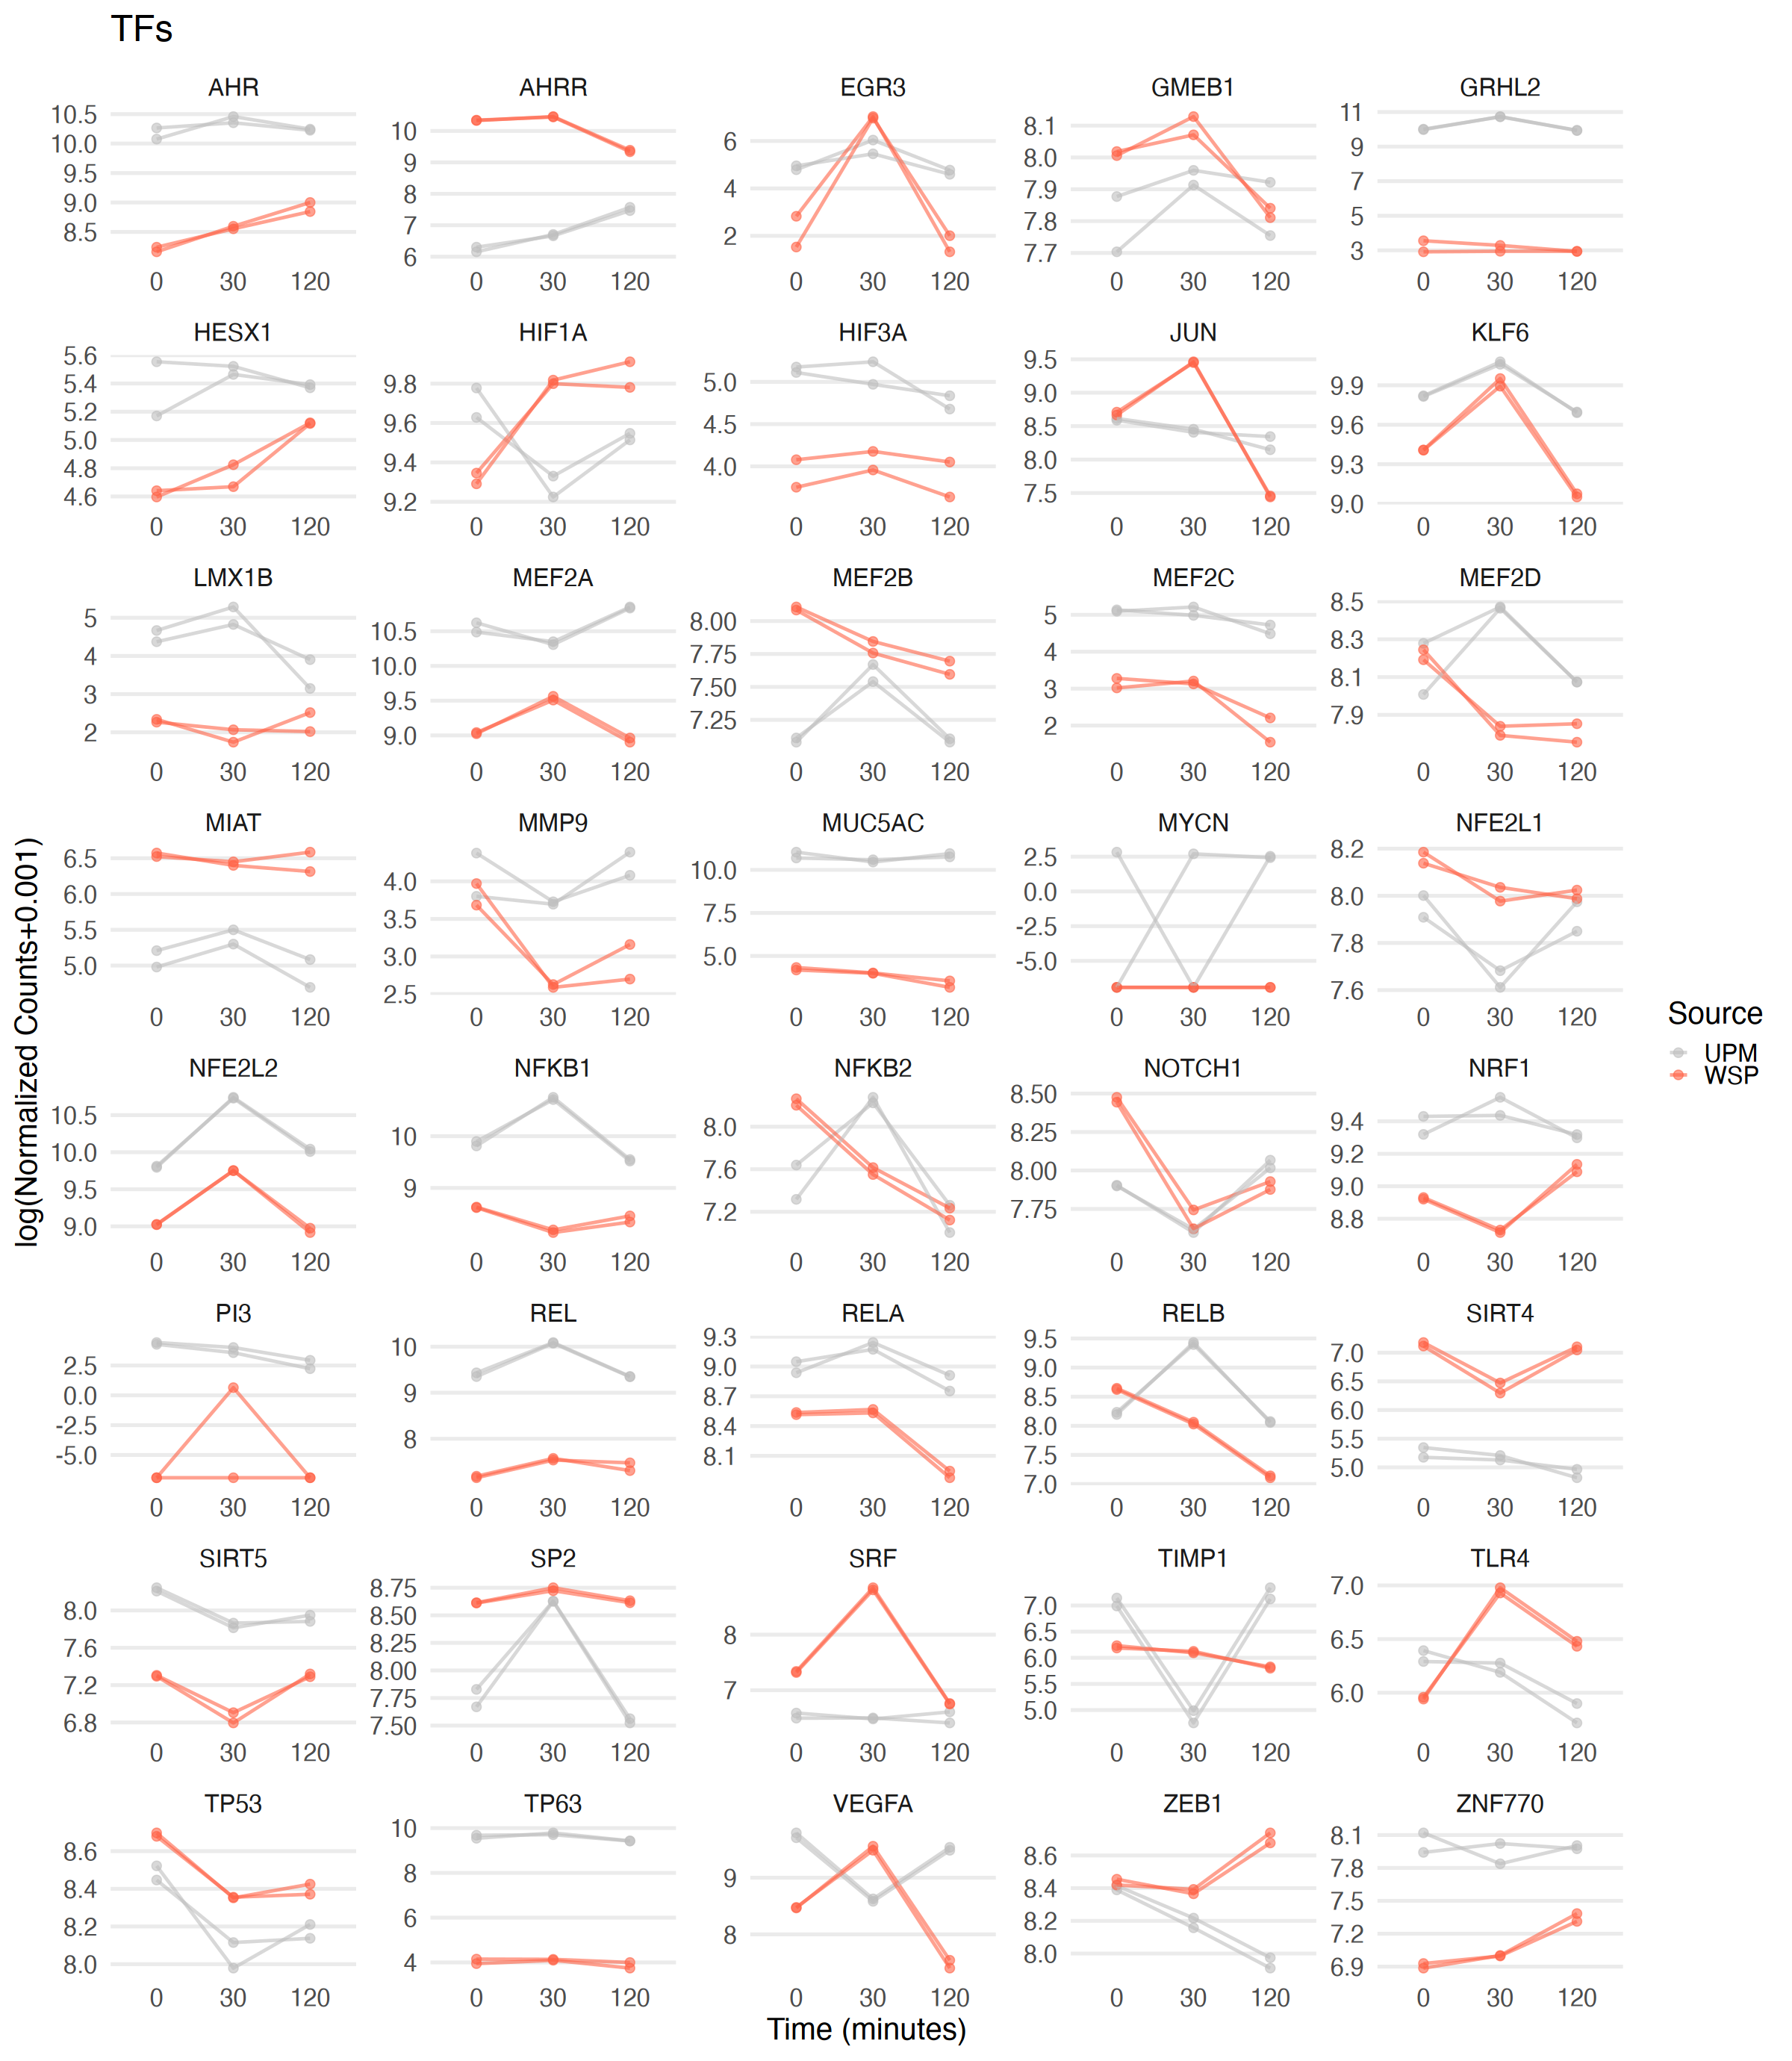

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)

#use_genes = c("AHRR")
counts_scaled_long_plot = counts_scaled_long[counts_scaled_long$Source != "ADP",]
counts_scaled_long_plot = counts_scaled_long_plot[counts_scaled_long_plot$Gene %in% c(tf_genes, "EGR3", "SRF", "SP2"),]
ggplot(counts_scaled_long_plot, aes(x=Time, y=Scaled, group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "TFs", x = "Time (minutes)", y = "Normalized Counts") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 
options(repr.plot.width=20, repr.plot.height=23)
ggplot(counts_scaled_long_plot, aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free", ncol=5) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

pdf 
  2

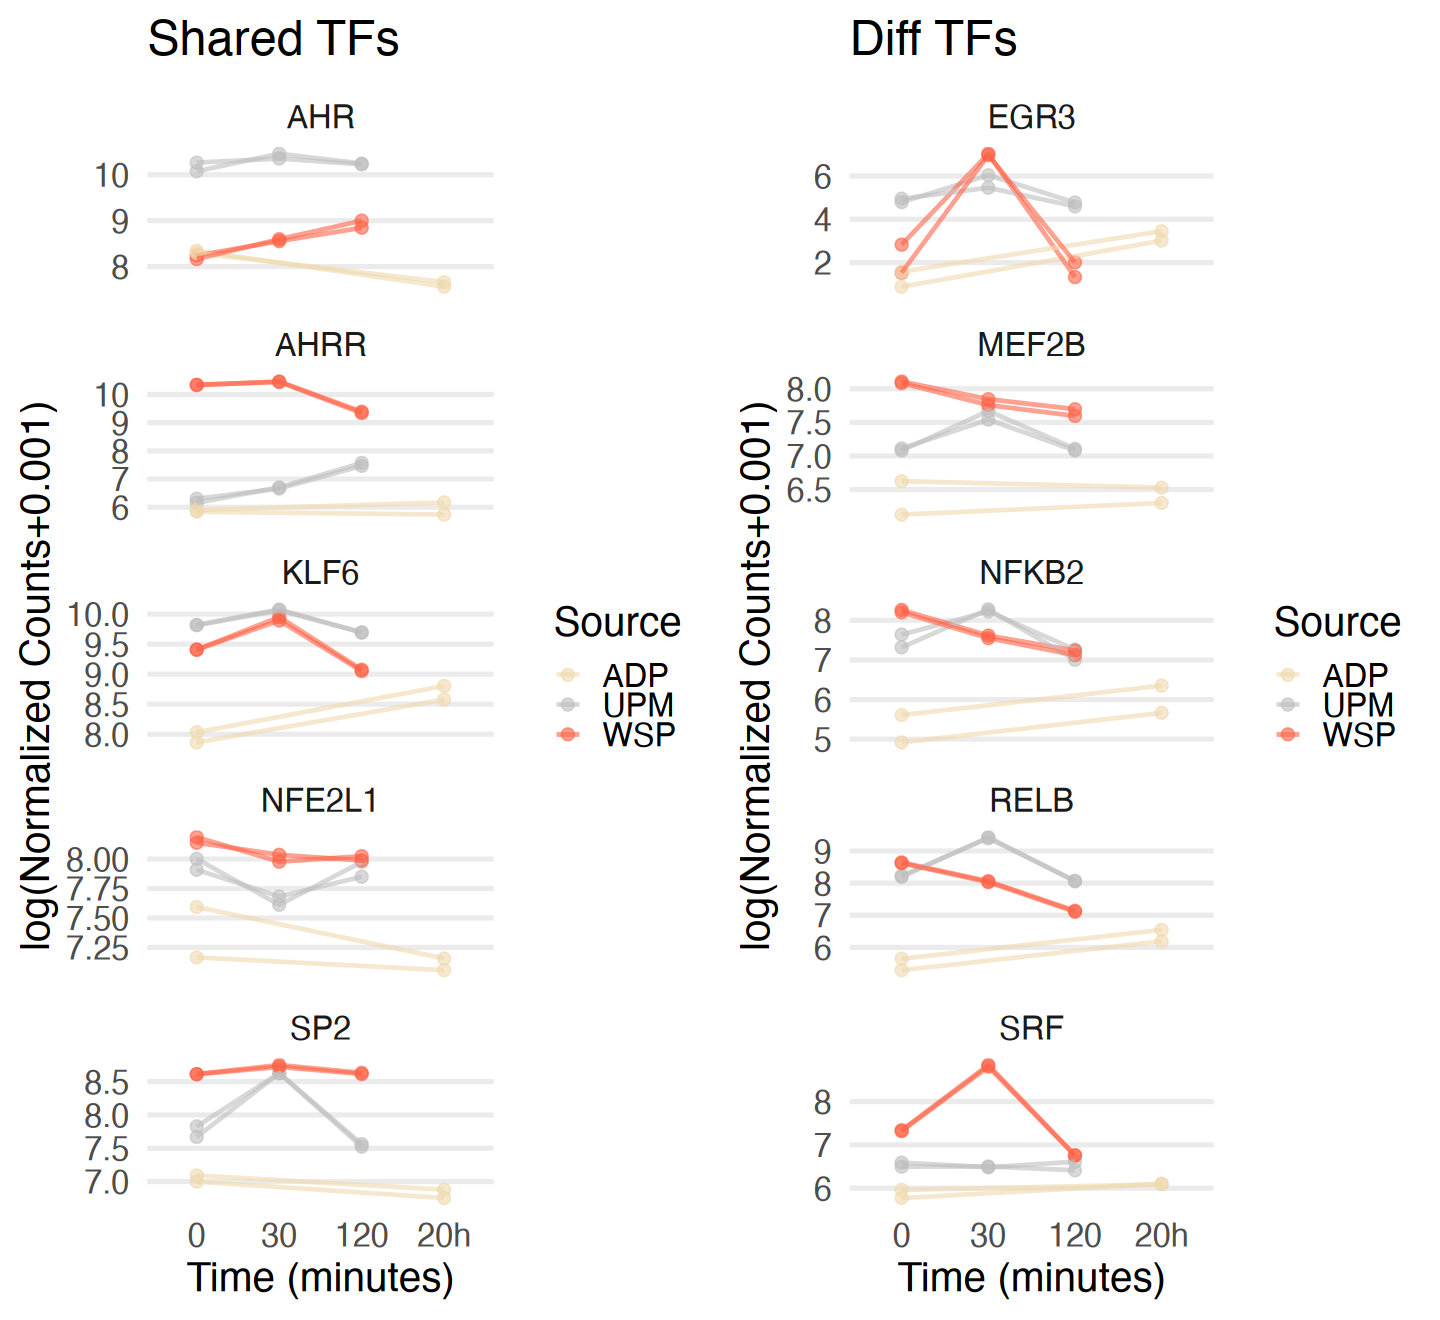

In [83]:
options(repr.plot.width=12, repr.plot.height=11)
p1 <- ggplot(counts_scaled_long_plot[counts_scaled_long_plot$Gene %in% c("AHR", "AHRR", "KLF6", "SP2", "NFE2L1"),], aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free_y", ncol=1) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "Shared TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

p2 <- ggplot(counts_scaled_long_plot[counts_scaled_long_plot$Gene %in% c("SRF", "RELB", "NFKB2", "EGR3", "MEF2B"),], aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free_y", ncol=1) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "Diff TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 
library(cowplot)
pdf("./plots/TF_exp_withADP_levels.pdf", width=10, height=11)
plot_grid(p1, p2, nrow=1)
dev.off()
plot_grid(p1, p2, nrow=1)

pdf 
  2

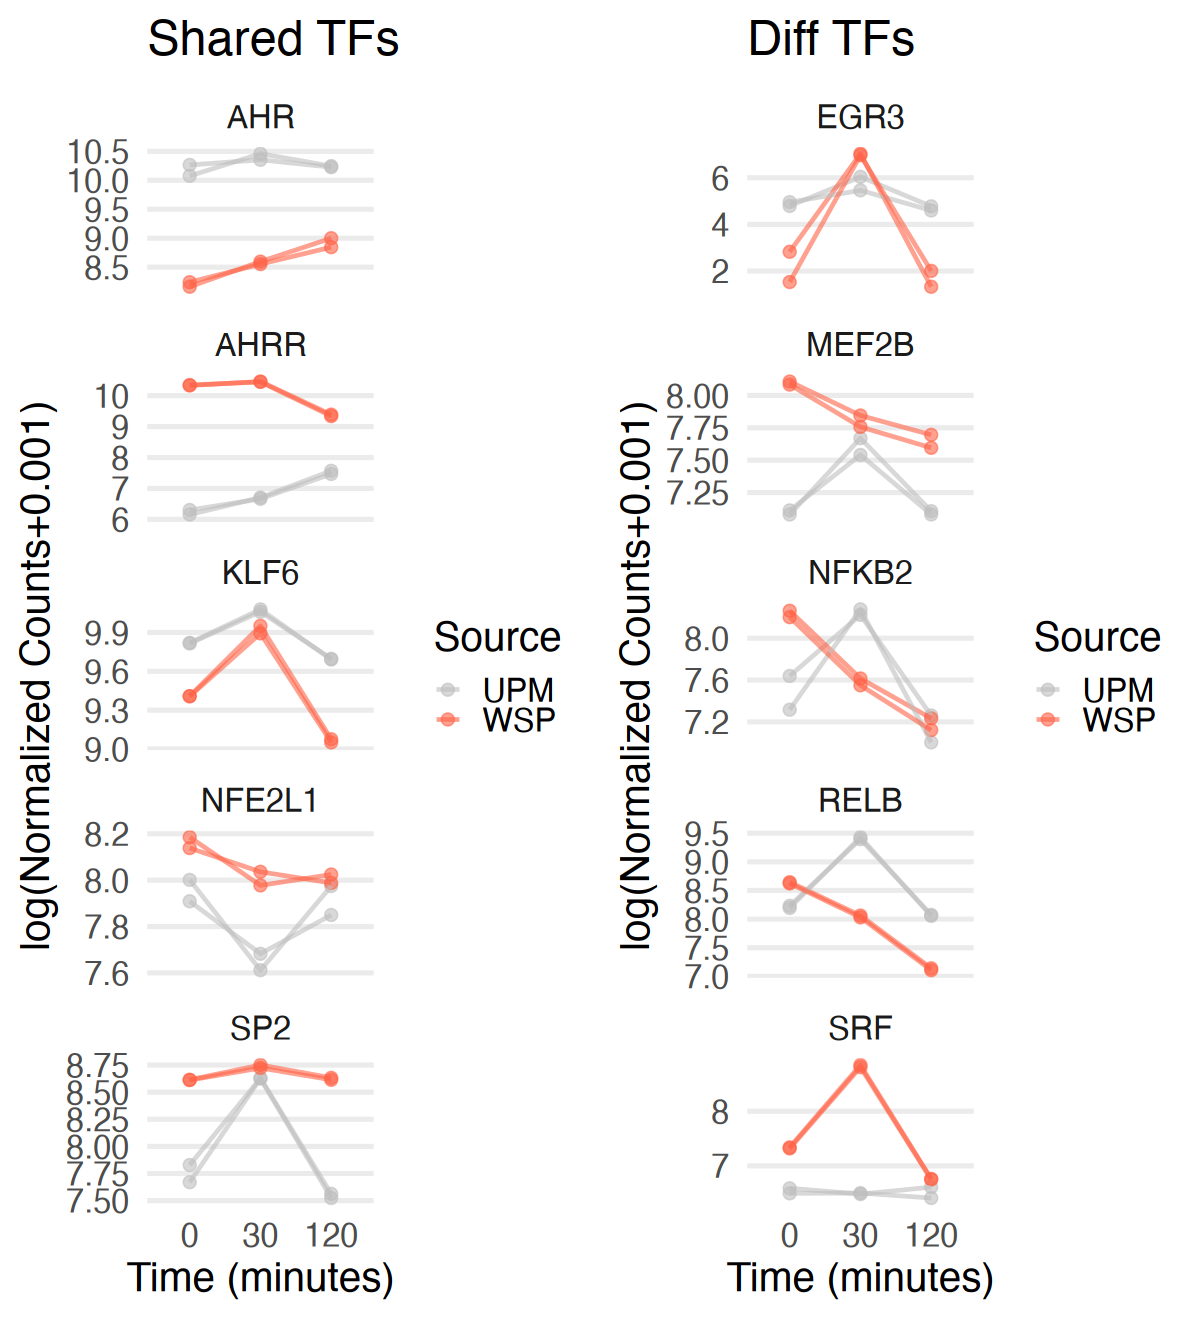

In [77]:
options(repr.plot.width=10, repr.plot.height=11)
p1 <- ggplot(counts_scaled_long_plot[counts_scaled_long_plot$Gene %in% c("AHR", "AHRR", "KLF6", "SP2", "NFE2L1"),], aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free_y", ncol=1) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "Shared TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 

p2 <- ggplot(counts_scaled_long_plot[counts_scaled_long_plot$Gene %in% c("SRF", "RELB", "NFKB2", "EGR3", "MEF2B"),], aes(x=Time, y=log(Count+0.001), group=Group, color=Source)) + geom_point(size = 3, alpha=0.6) +
      geom_line(linewidth = 1, alpha=0.6) +
      facet_wrap(~Gene, scales="free_y", ncol=1) +
      theme_minimal(base_size = 24) +
	  scale_color_manual(values=color_map) +
      labs(title = "Diff TFs", x = "Time (minutes)", y = "log(Normalized Counts+0.001)") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank()) 
library(cowplot)
pdf("./plots/TF_exp_levels.pdf", width=10, height=11)
plot_grid(p1, p2, nrow=1)
dev.off()
plot_grid(p1, p2, nrow=1)



In [81]:
check = counts_scaled[counts_scaled$Gene %in% UPM_time_sig[["ER"]],]
dim(check)
check[1:4,]

[1] 4134    6

Gene,Sample,Count,Time,Replicate,Scaled
<chr>,<chr>,<dbl>,<fct>,<chr>,<dbl>
TMEM217,UPM120_1,876.583,120,Rep1,0.00000000
TMEM217,UPM120_2,1040.465,120,Rep2,0.04670242
TMEM217,UPM30_1,3871.783,30,Rep1,0.85356253
TMEM217,UPM30_2,4385.641,30,Rep2,1.00000000


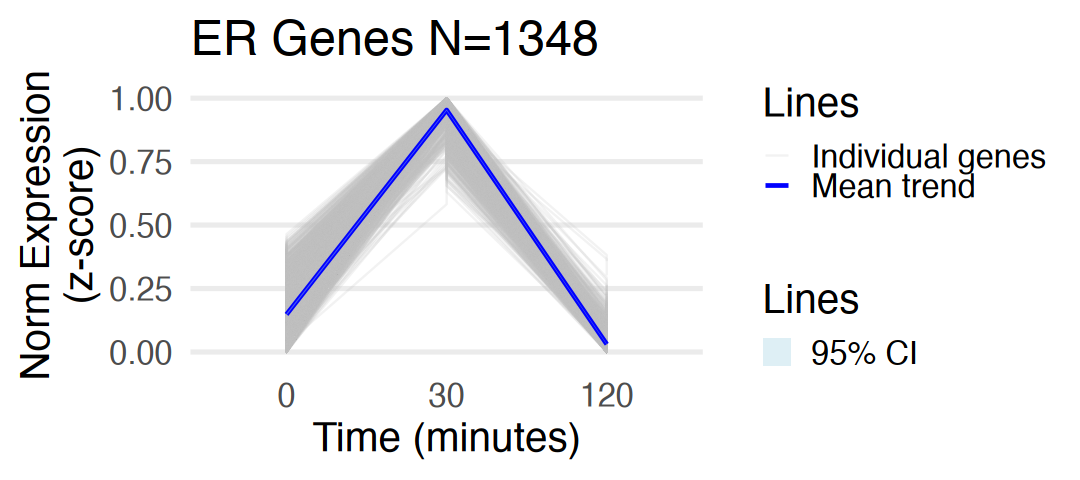

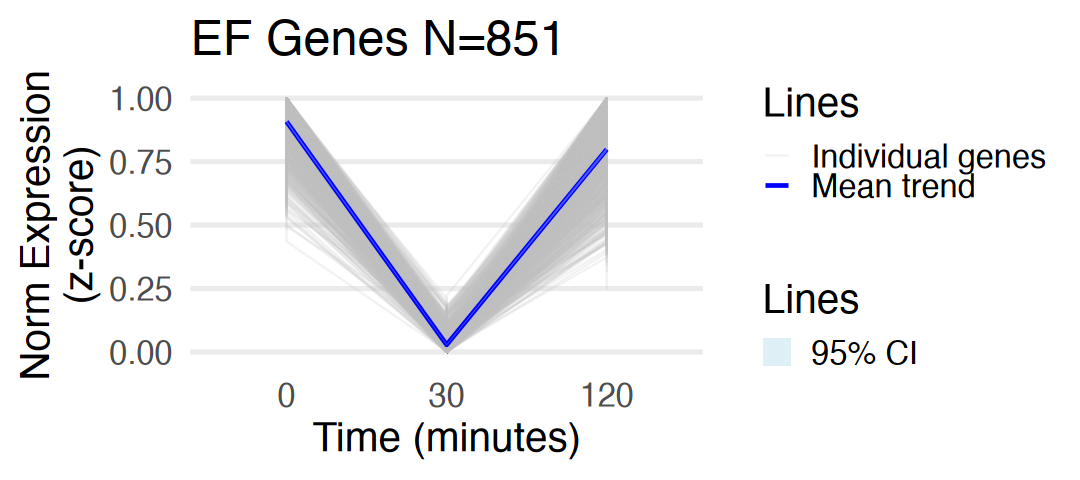

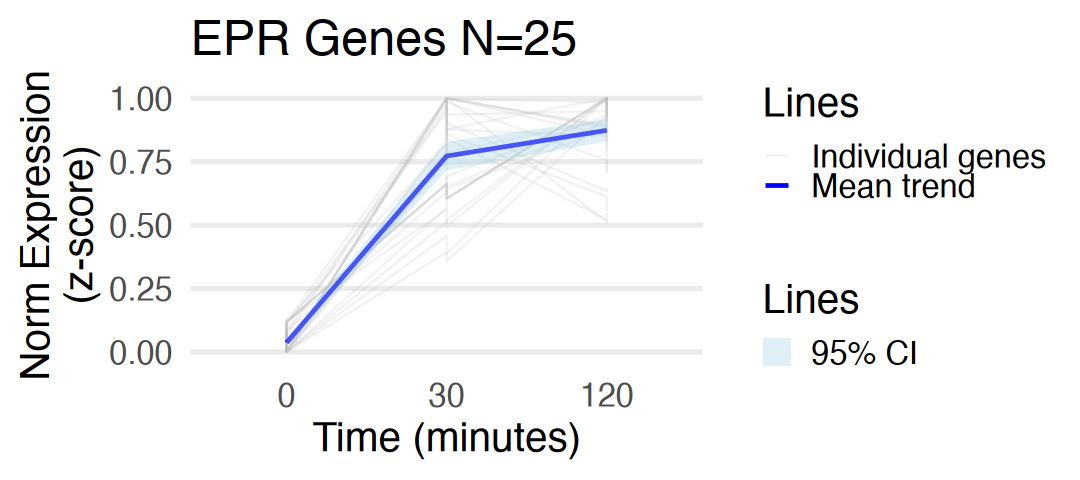

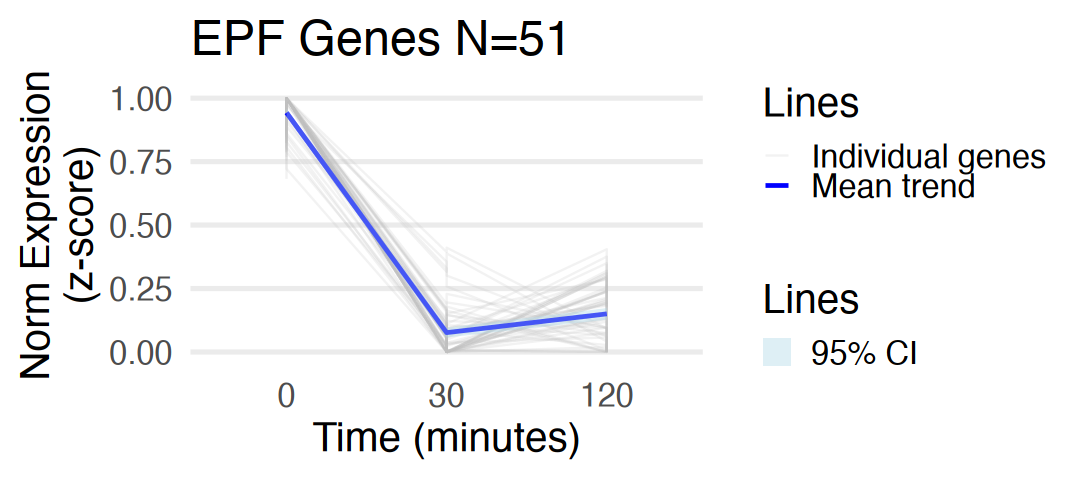

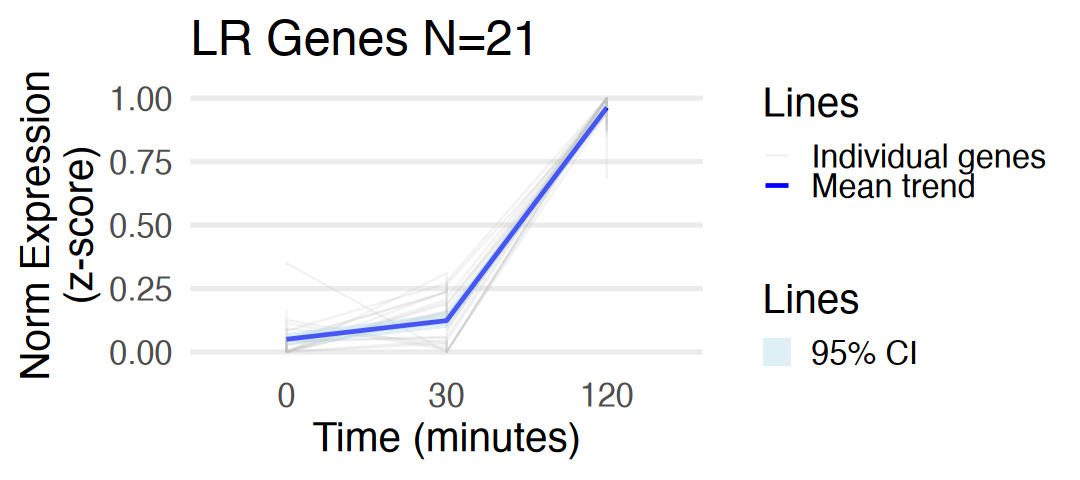

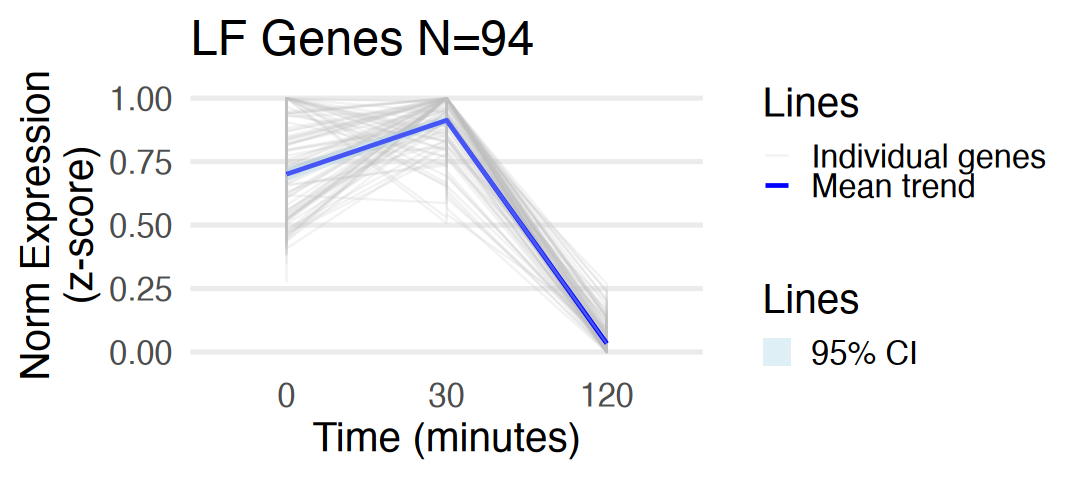

In [ ]:
# Consider with the different time points
options(repr.plot.height=height_use, repr.plot.width=9)
for (timepoint in names(UPM_10_time_sig)) {
    use_genes = UPM_10_time_sig[[timepoint]]
# Step 3: Plot: Mean ± 95% CI per time point
p = ggplot(counts_upm_scaled[counts_upm_scaled$Gene %in% use_genes,], aes(x = Time, y = Scaled)) +
    geom_line(aes(group = Gene, color = "Individual genes"), alpha = 0.2) +
  stat_summary(fun = mean, geom = "line", aes(group = 1, color = "Mean trend"), linewidth = 1) +
  stat_summary(fun.data = mean_cl_normal, geom = "ribbon", aes(group = 1, fill = "95% CI"),  alpha = 0.4) +
  theme_minimal(base_size = 24) +
  labs(
    title = paste0(timepoint, " Genes N=", length(use_genes)),
    y = "Norm Expression\n(z-score)",
    x = "Time (minutes)"
  ) +
    scale_color_manual(name = "Lines", values = c(
    "Individual genes" = "gray",
    "Mean trend" = "blue"
  )) +
  scale_fill_manual(name = "Lines", values = c(
    "95% CI" = "lightblue"
  )) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank()
  )
    print(p)
    ggsave(paste0("UPM_", timepoint, "_p10_meta_plot.pdf"), height=height_use, width=9)
    }

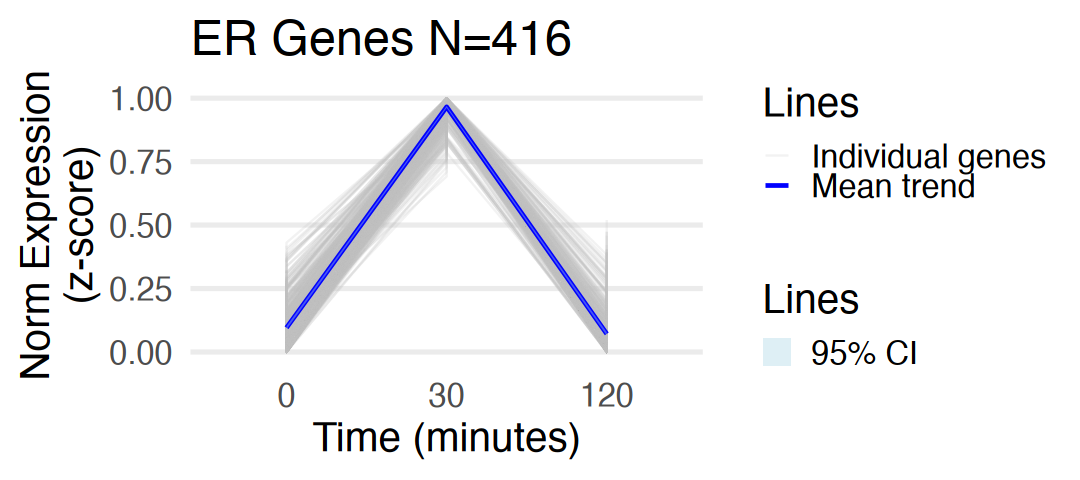

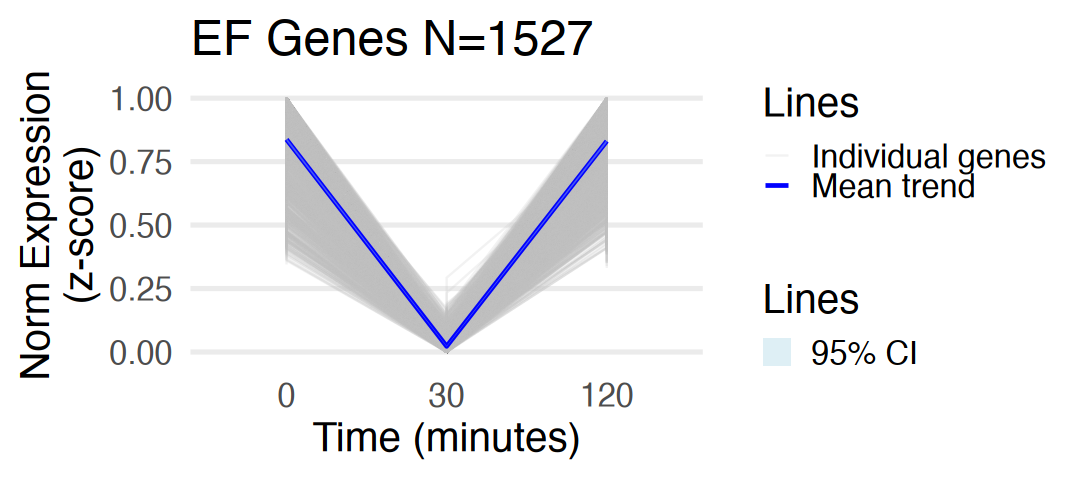

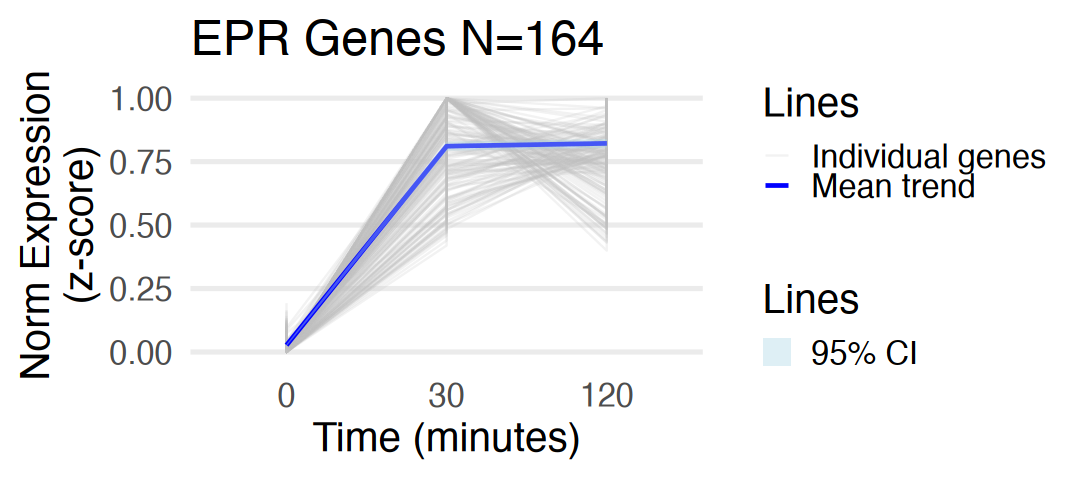

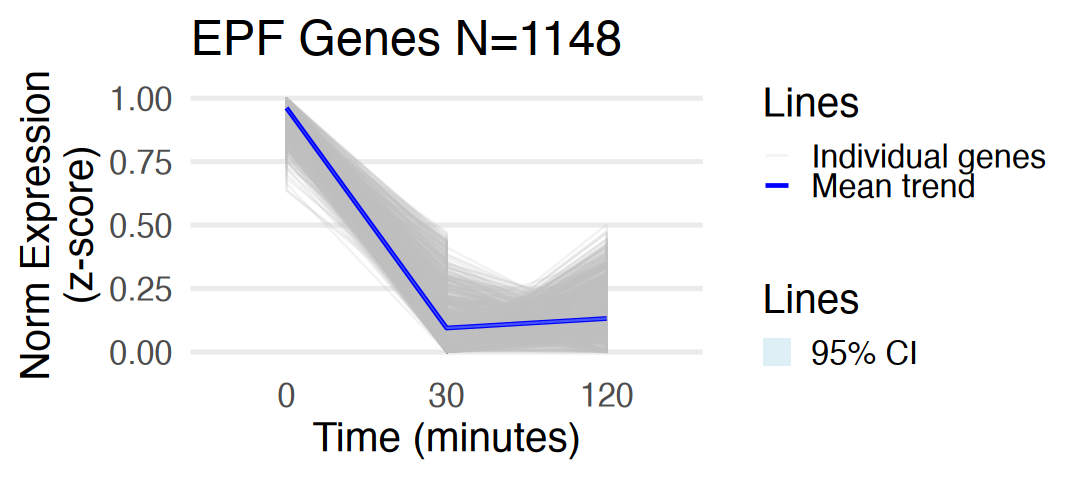

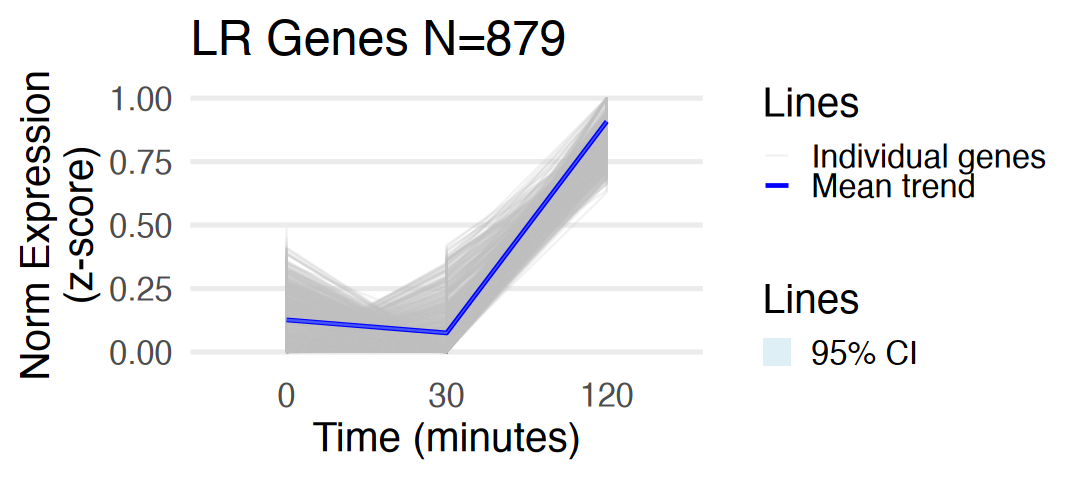

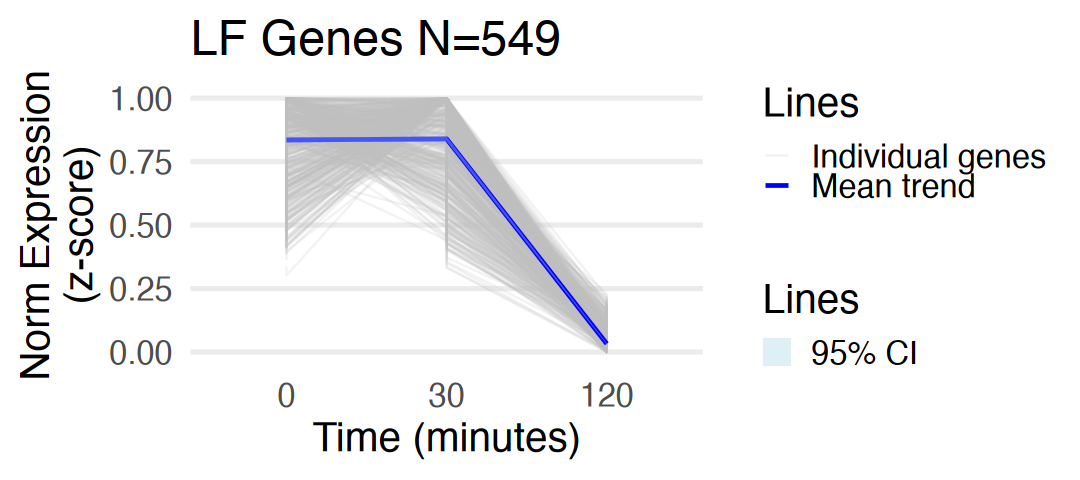

In [28]:
# Consider with the different time points
options(repr.plot.height=height_use, repr.plot.width=9)
for (timepoint in names(WSP_10_time_sig)) {
    use_genes = WSP_10_time_sig[[timepoint]]
# Step 3: Plot: Mean ± 95% CI per time point
p = ggplot(counts_wsp_scaled[counts_wsp_scaled$Gene %in% use_genes,], aes(x = Time, y = Scaled)) +
    geom_line(aes(group = Gene, color = "Individual genes"), alpha = 0.2) +
  stat_summary(fun = mean, geom = "line", aes(group = 1, color = "Mean trend"), linewidth = 1) +
  stat_summary(fun.data = mean_cl_normal, geom = "ribbon", aes(group = 1, fill = "95% CI"),  alpha = 0.4) +
  theme_minimal(base_size = 24) +
  labs(
    title = paste0(timepoint, " Genes N=", length(use_genes)),
    y = "Norm Expression\n(z-score)",
    x = "Time (minutes)"
  ) +
    scale_color_manual(name = "Lines", values = c(
    "Individual genes" = "gray",
    "Mean trend" = "blue"
  )) +
  scale_fill_manual(name = "Lines", values = c(
    "95% CI" = "lightblue"
  )) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank()
  )
    print(p)
    ggsave(paste0("WSP_", timepoint, "_p10_meta_plot.pdf"), height=height_use, width=9)
    }

### Plot Jaccard indices as heatmaps

In [5]:
names(WSP_sig_10)

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

In [6]:
# add the total rise and total fall
WSP_10_time_sig$Rise <- union(WSP_sig_10$P120_vs_Veh_up, WSP_sig_10$P30_vs_Veh_up)
WSP_10_time_sig$Fall <- union(WSP_sig_10$P120_vs_Veh_down, WSP_sig_10$P30_vs_Veh_down)
length(WSP_10_time_sig$Rise)
length(WSP_10_time_sig$Fall)

WSP_10_time_sig$Time_Rise <- union(WSP_10_time_sig$LR, union(WSP_10_time_sig$ER, WSP_10_time_sig$EPR))
WSP_10_time_sig$Time_Fall <- union(WSP_10_time_sig$LF, union(WSP_10_time_sig$EF, WSP_10_time_sig$EPF))
length(WSP_10_time_sig$Time_Rise)
length(WSP_10_time_sig$Time_Fall)

[1] 2445

[1] 5197

[1] 1459

[1] 3224

In [7]:
jaccard_index_ER <- function(X) {
	Y=UPM_10_time_sig[["ER"]]
	return(length(intersect(X,Y))/length(union(X,Y)))
	}
jaccard_index_EF <- function(X) {
	Y=UPM_10_time_sig[["EF"]]
	return(length(intersect(X,Y))/length(union(X,Y)))
	}

ji_ER = lapply(WSP_10_time_sig, jaccard_index_ER)
ji_EF = lapply(WSP_10_time_sig, jaccard_index_EF)
ji_ER
ji_EF

$ER
[1] 0.04875149

$EF
[1] 0.01950355

$EPR
[1] 0.03067485

$EPF
[1] 0.007670569

$LR
[1] 0.06759348

$LF
[1] 0.02374528

$Rise
[1] 0.1400661

$Fall
[1] 0.0300598

$Time_Rise
[1] 0.1055534

$Time_Fall
[1] 0.02649304

$ER
[1] 0.01441153

$EF
[1] 0.08982585

$EPR
[1] 0.002964427

$EPF
[1] 0.07242489

$LR
[1] 0.0218547

$LF
[1] 0.02115244

$Rise
[1] 0.03485086

$Fall
[1] 0.1000364

$Time_Rise
[1] 0.02575488

$Time_Fall
[1] 0.09690444

In [8]:
ER_df = data.table("Category"=c("Early", "Plateau", "Late", "Total"),
"Rise"=c(ji_ER$ER, ji_ER$EPR, ji_ER$LR, ji_ER$Rise), "Fall"=c(ji_ER$EF, ji_ER$EPF, ji_ER$LF, ji_ER$Fall))
ER_df
EF_df = data.table("Category"=c("Early", "Plateau", "Late", "Total"),
"Rise"=c(ji_EF$ER, ji_EF$EPR, ji_EF$LR, ji_EF$Rise), "Fall"=c(ji_EF$EF, ji_EF$EPF, ji_EF$LF, ji_EF$Fall))
EF_df

Category,Rise,Fall
<chr>,<dbl>,<dbl>
Early,0.04875149,0.019503546
Plateau,0.03067485,0.007670569
Late,0.06759348,0.023745278
Total,0.14006613,0.030059805


Category,Rise,Fall
<chr>,<dbl>,<dbl>
Early,0.014411529,0.08982585
Plateau,0.002964427,0.07242489
Late,0.021854696,0.02115244
Total,0.034850863,0.10003638


Warning message:
"package 'circlize' was built under R version 4.4.1"
circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




pdf 
  2

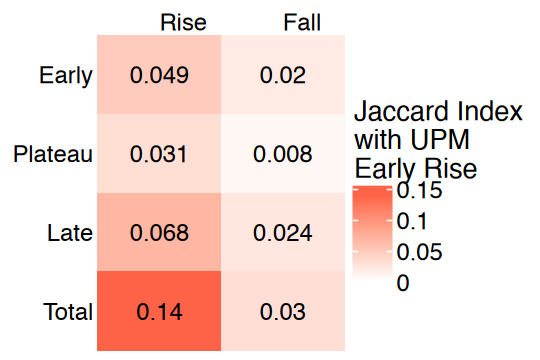

In [11]:
library(ComplexHeatmap)
library(circlize)
options(repr.plot.width=4.5, repr.plot.height=3)
ER_mat = as.matrix(ER_df[,c("Rise", "Fall"), with=FALSE])
rownames(ER_mat) = ER_df$Category
col_fun = colorRamp2(c(0, max(ER_mat)), c("white", "#ff6347ff"))
H = Heatmap(ER_mat, 
	name = "Jaccard Index\nwith UPM\nEarly Rise", col = col_fun,
	cluster_rows=FALSE, cluster_columns=FALSE, 
	# Axis label controls
  column_names_rot = 0,   # horizontal x-axis labels
  column_names_side = "top",
  row_names_side = "left", # move y-axis labels to left
   # 🔥 LEGEND size larger
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = 16, fontface = "bold"),  # title size
    labels_gp = gpar(fontsize = 14),                    # tick labels
    grid_width = unit(8, "mm"),                         # width of color bar
    grid_height = unit(8, "mm")                         # height of color steps
  ),
  # Increase label sizes
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 14),
	 # Add text annotations
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid::grid.text(
      label = round(ER_mat[i, j], 3),  # round values
      x = x, y = y,
      gp = grid::gpar(fontsize = 14)   # 🔥 increase font size here
    )
  }
)

draw(H)
pdf("UPM_ER_WSP_Gene_Jaccard_Heatmaps.pdf", height=3, width=4.5)
draw(H)
dev.off()

pdf 
  2

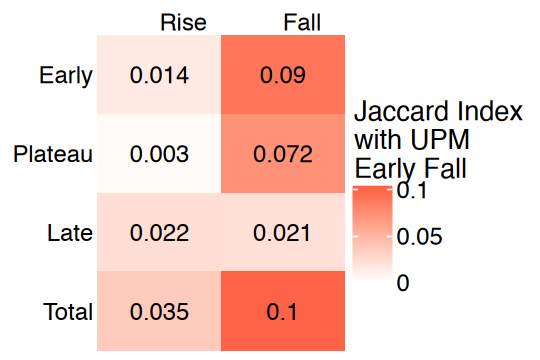

In [12]:
#library(ComplexHeatmap)
options(repr.plot.width=4.5, repr.plot.height=3)
#library(circlize)
EF_mat = as.matrix(EF_df[,c("Rise", "Fall"), with=FALSE])
rownames(EF_mat) = EF_df$Category
col_fun = colorRamp2(c(0, max(EF_mat)), c("white", "#ff6347ff"))
H = Heatmap(EF_mat, 
	name = "Jaccard Index\nwith UPM\nEarly Fall", col = col_fun,
	cluster_rows=FALSE, cluster_columns=FALSE, 
	# Axis label controls
  column_names_rot = 0,   # horizontal x-axis labels
  column_names_side = "top",
  row_names_side = "left", # move y-axis labels to left
   # 🔥 LEGEND size larger
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = 16, fontface = "bold"),  # title size
    labels_gp = gpar(fontsize = 14),                    # tick labels
    grid_width = unit(8, "mm"),                         # width of color bar
    grid_height = unit(8, "mm")                         # height of color steps
  ),
  # Increase label sizes
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 14),
	 # Add text annotations
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid::grid.text(
      label = round(EF_mat[i, j], 3),  # round values
      x = x, y = y,
      gp = grid::gpar(fontsize = 14)   # 🔥 increase font size here
    )
  }
)

draw(H)
pdf("UPM_EF_WSP_Gene_Jaccard_Heatmaps.pdf", height=3, width=4.5)
draw(H)
dev.off()

### GO Plots

In [110]:
run_go_analysis <- function(gene_symbols) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

In [111]:
GO_ER = run_go_analysis(UPM_10_time_sig[["ER"]])

In [112]:
GO_EF = run_go_analysis(UPM_10_time_sig[["EF"]])
GO_EPR = run_go_analysis(UPM_10_time_sig[["EPR"]]) # UGT1A8...
GO_EPF = run_go_analysis(UPM_10_time_sig[["EPF"]])
GO_LR = run_go_analysis(UPM_10_time_sig[["LR"]]) # UGT1A3/4
GO_LF = run_go_analysis(UPM_10_time_sig[["LF"]])

In [121]:
GO_LF

#
# over-representation test
#
#...@organism 	 Homo sapiens 
#...@ontology 	 GOALL 
#...@keytype 	 SYMBOL 
#...@gene 	 chr [1:94] "SGPP2" "CRACR2A" "NIBAN1" "SAMD4A" "PCSK5" "CHST15" "EMP1" ...
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...37 enriched terms found
'data.frame':	37 obs. of  13 variables:
 $ ONTOLOGY      : chr  "BP" "BP" "BP" "BP" ...
 $ ID            : chr  "GO:0016049" "GO:0071526" "GO:0048588" "GO:0060560" ...
 $ Description   : chr  "cell growth" "semaphorin-plexin signaling pathway" "developmental cell growth" "developmental growth involved in morphogenesis" ...
 $ GeneRatio     : chr  "11/69" "4/69" "7/69" "7/69" ...
 $ BgRatio       : chr  "496/18888" "44/18888" "238/18888" "243/18888" ...
 $ RichFactor    : num  0.0222 0.0909 0.0294 0.0288 0.0702 ...
 $ FoldEnrichment: num  6.07 24.89 8.05 7.89 19.21 ...
 $ zScore        : num  6.93 9.6 6.63 6.54 8.34 ...
 $ pvalue        : num  1.69e-06 1.98e-05 2.56e-05 2.93e-05 5.57e-05 ...
 $ p.adjust      : num  0.0027

#### Number of Significant Terms and Genes:
1. ER: 120 ETerms, 1348 genes
2. EF: 63 ETerms, 851 genes
3. GO_EPR: 35 ETerms, 25 genes
4. GO_EPF: 14 ETerms, 51 genes
5. GO_LR: 36 ETerms, 21 genes
6. GO_LF: 37 ETerms, 94 genes

### Summarize GO plots

In [162]:
unique(using$ONTOLOGY)

[1] "BP" "CC" "MF"

[1] 120

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0044782,BP,GO:0044782,cilium organization,52/1159,412/18888,0.1262136,2.056879,5.545629,6.055653e-07,0.002163559,0.001977451,NEDD9/TBC1D32/RTTN/CPLANE1/TTLL3/LIMK2/ALPK1/ABLIM1/UBE2B/ARF4/SCLT1/B9D2/DZIP1L/BBOF1/CFAP410/TTBK2/RPGR/TTC21B/CFAP206/MAK/TMEM231/BBS9/RFX2/DYNC2H1/IFT80/RFX3/IFT46/CFAP54/SPAG6/HOATZ/CEP120/PCNT/CEP128/MAPRE1/CEP70/WDPCP/USP9X/PIBF1/SPATA6/KIF24/DNAH7/WWTR1/IQCG/CFAP47/CYLD/TRAF3IP1/CC2D2A/GSK3B/SPEF2/NECTIN2/TTC29/CFAP61,52
GO:0009649,BP,GO:0009649,entrainment of circadian clock,11/1159,30/18888,0.3666667,5.975496,6.973171,8.189096e-07,0.002163559,0.001977451,PER2/BMAL2/PER1/GNAQ/PPP1CB/RBM4/FBXL3/CRY1/CRY2/FBXL17/CRTC1,11


,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0070064,MF,GO:0070064,proline-rich region binding,7/1183,17/18522,0.4117647,6.446920,5.868721,4.692872e-05,0.004990087,0.004610541,GAREM1/NEDD4/GHR/WBP4/BAIAP2L1/ITSN1/CYLD,7,Other
GO:0003713,MF,GO:0003713,transcription coactivator activity,36/1183,271/18522,0.1328413,2.079871,4.677628,2.427230e-05,0.003109762,0.002873233,PER2/NCOA7/ARID5B/USP16/MRTFB/LMO3/MRTFA/ARID1B/NCOA1/SMARCA2/PDLIM1/TRERF1/MAML3/NCOA2/THRAP3/KAT6B/MAK/KMT2C/MTA3/MAML2/JMY/PMF1/CREBBP/TRIM38/NUP98/SIRT1/IL31RA/RBPMS/LPIN1/ACTN1/WWTR1/SMARCC1/TOX3/KDM4C/FUS/HCFC1,36,Other
GO:0016607,CC,GO:0016607,nuclear speck,44/1201,416/19894,0.1057692,1.752018,3.929023,2.159514e-04,0.009728365,0.008094614,NAMPT/BCAS2/PSME4/DAZAP2/NRDE2/FTO/SRPK2/RBM39/HBP1/BARD1/SMC5/SERPINB13/MAML3/NFKBIZ/GLI3/IL16/THRAP3/CCNL1/BCLAF1/YTHDC1/NR4A2/ARHGAP18/RBM4/CIR1/MAML2/DENND1B/CHTOP/SMU1/MECOM/ITPKC/RSRC1/WBP4/SCAPER/CRY2/SREK1/TCIM/ZBTB16/SRSF6/SMC4/PPP4R3A/CWC25/HDAC4/PARN/DDX5,44,Other


Warning message:
“Cannot compute density for groups with fewer than two datapoints.”
Warning message:
“Cannot compute density for groups with fewer than two datapoints.”


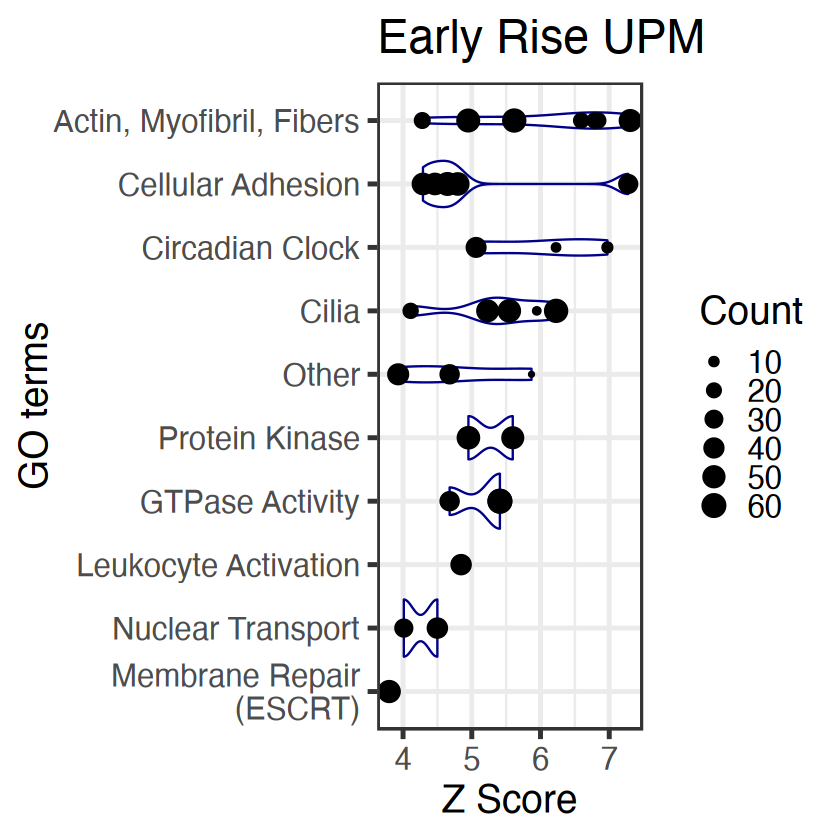

In [272]:
options(repr.plot.width=7, repr.plot.height=7)
#go_early_risep$Description
using = as.data.frame(GO_ER)
length(unique(using$Description))
using[1:2,]
# filter for at least more than 1 gene
using = using[using$Count > 1 & using$qvalue < 0.01,]
using$Group <- "Other"
using[grepl("membrane|envelope|ESCRT I complex", using$Description),]$Group <- "Membrane Repair\n(ESCRT)"
using[grepl("junction|desmosome|cadherin|integrin|adhesion|adherens|immunological synapse|tubulin binding", using$Description),]$Group <- "Cellular Adhesion"
using[grepl("contractile fiber|Z disc|I band|actin|myofibril|actomyosin|stress fiber|cell cortex", using$Description),]$Group <- "Actin, Myofibril, Fibers"
using[grepl("brush|cilia|axon|plasma membrane bounded|microtub|leading edge|apical|ciliu|lamellipodium|flagel|filopodium|polar", using$Description),]$Group <- "Cilia"
#using[grepl("cilia|ruffle|growth cone|ciliary|polarized growth|filopodium|lamellipodium|cell leading edge", using$Description),]$Group <- "Cellular Feet"
using[grepl("leukocyte|lymphocyte|activation", using$Description),]$Group <- "Leukocyte Activation"
using[grepl("GTPase|nucleoside-triphosphatase", using$Description),]$Group <- "GTPase Activity"
using[grepl("protein serine", using$Description),]$Group <- "Protein Kinase"
# using[grepl("growth factor", using$Description),]$Group <- "Growth Factor Activity"
using[grepl("golgi|Golgi|vesicle|protein localization|transport|endosome", using$Description),]$Group <- "Nuclear Transport"
using[grepl("circadian|photoperiod|rhythmic", using$Description),]$Group <- "Circadian Clock"
#using[grepl("T cell differentiation|mononuclear", using$Description),]$Group <- "T cell differentiation"
#using[grepl("MHC class II|interferon", using$Description),]$Group <- "MHC class II/interferon"
#using[grepl("ribonucleoprotein|splicing", using$Description),]$Group <- "Splicing"
# using[grepl("nuclear receptor binding", using$Description),]$Group <- "Nuclear Receptor Binding"
# using[grepl("SREBP|sterol", using$Description),]$Group <- "Sterol Depletion (SREBP)"
#using[grepl("autophag", using$Description),]$Group <- "Autophagy"

#using[grepl("viral", using$Description),]$Group <- "Virus"
testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
pER <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=23) + 
labs(y="GO terms", x="Z Score") + ggtitle("Early Rise UPM ")
pER
ggsave("GO_total_ER_p10.pdf", pER, height=7, width=7)

[1] 63

ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>



                   Cellular Adhesion                       GTPase binding 
                                   6                                   16 
Hyaluronan biosythesis\n& Glycolysis     Phospho/Glycerolipid\nMetabolism 
                                  35                                    6 

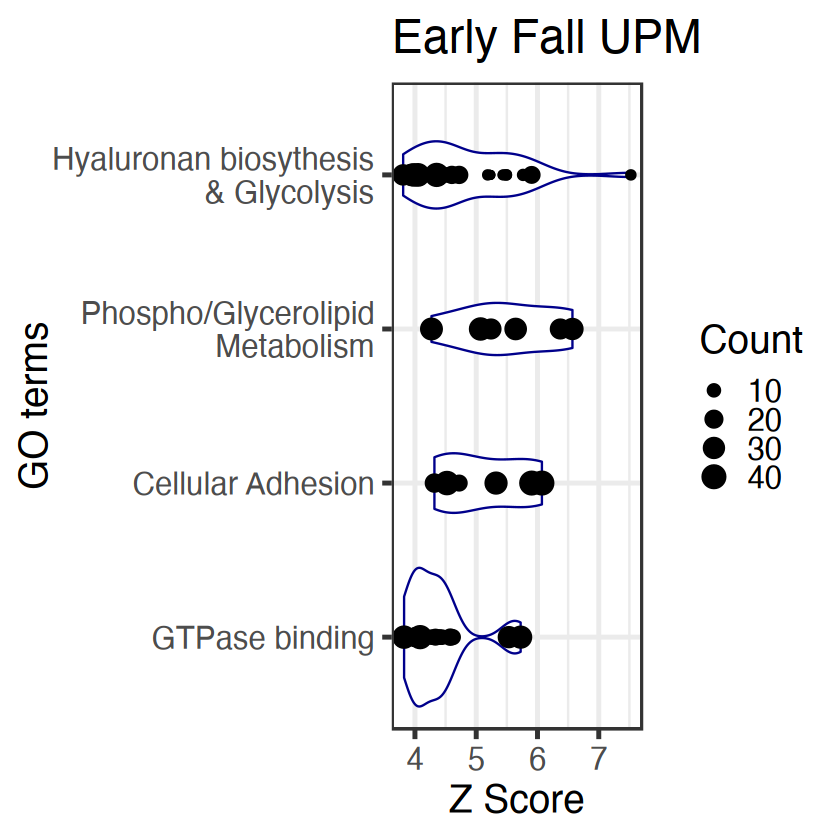

In [274]:

#go_early_risep$Description
using = as.data.frame(GO_EF)
using = using[using$Count > 1 & using$qvalue < 0.05,]
length(unique(using$Description))
#using[1:2,]
using$Group <- "Other"

using[grepl("hyaluronan|ADP|ATP|organophosphate|hexose|pyruvate|pyridine|purine|carbohydrate|glucose||monosaccharide|glycoly|ribose phosphate|pyruvate|fructose|NAD", using$Description),]$Group <- "Hyaluronan biosythesis\n& Glycolysis"
using[grepl("GTPase|ribonucleotide|nucleotide|nucleoside", using$Description),]$Group <- "GTPase binding"
using[grepl("phospholipid|glycerolipid", using$Description),]$Group <- "Phospho/Glycerolipid\nMetabolism"
using[grepl("adhesion|fibronectin|integrin|cadherin|junction|semaphorin-plexin", using$Description),]$Group <- "Cellular Adhesion"
# using[grepl("alcohol", using$Description),]$Group <- "Alcohol metabolism"
# using[grepl("hypoxia|oxygen", using$Description),]$Group <- "Response to Hypoxia"
# using[grepl("Vascular Permeability|vascul|angiogenesis", using$Description),]$Group <- "Vascularture"
# using[grepl("TOR", using$Description),]$Group <- "TOR complex"
# using[grepl("ficolin-1-rich", using$Description),]$Group <- "Neutrophil"
# using[grepl("vesicle|secretory", using$Description),]$Group <- "Vesicles/Secretion"
# using[grepl("sterol|steroid", using$Description),]$Group <- "Steral/Steroid Metabolism"
# using[grepl("iron ion", using$Description),]$Group <- "Iron binding"
# using[grepl("development|reproducti|female pregnancy|multi-multicellular|heart morphogenesis|cell growth|growth|ERK|morphogenesis", using$Description),]$Group <- "Development & ERK1/2 cascade"

# using[grepl("SREBP|sterol", using$Description),]$Group <- "Sterol Depletion (SREBP)"
# using[grepl("autophagy", using$Description),]$Group <- "Autophagy"
testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
table(using$Group)
pEF <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=23) + 
labs(y="GO terms", x="Z Score") + ggtitle("Early Fall UPM")
pEF
ggsave("GO_total_EF_p10.pdf", pEF, height=7, width=7)

[1] "UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1"               
 [2] "UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1/ALDH3A1"       
 [3] "UGT1A8/UGT1A9/UGT1A7/UGT1A1"                       
 [4] "TIPARP/UGT1A8/UGT1A9/UGT1A7/UGT1A1"                
 [5] "UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1/TFCP2L1"       
 [6] "TIPARP/UGT1A7/UGT1A1"                              
 [7] "TIPARP/UGT1A8/UGT1A7/UGT1A1"                       
 [8] "UGT1A8/UGT1A1"                                     
 [9] "UGT1A8/UGT1A7"                                     
[10] "CDK5RAP2/SPIRE2"                                   
[11] "UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1/GALNT10"       
[12] "TIPARP/UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1/GALNT10"
[13] "UGT1A8/UGT1A1/OSBPL10"                             
[14] "UGT1A10/UGT1A7"

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0009812,BP,GO:0009812,flavonoid metabolic process,5/23,13/18888,0.3846154,315.8528,39.65088,2.149170e-12,1.050944e-09,8.325207e-10,UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1,5
GO:0052695,BP,GO:0052695,cellular glucuronidation,5/23,21/18888,0.2380952,195.5280,31.14277,3.376553e-11,8.255673e-09,6.539851e-09,UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1,5
GO:0006063,BP,GO:0006063,uronic acid metabolic process,5/23,26/18888,0.1923077,157.9264,27.95799,1.087172e-10,1.329067e-08,1.052840e-08,UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1,5
GO:0019585,BP,GO:0019585,glucuronate metabolic process,5/23,26/18888,0.1923077,157.9264,27.95799,1.087172e-10,1.329067e-08,1.052840e-08,UGT1A8/UGT1A10/UGT1A9/UGT1A7/UGT1A1,5


,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0051293,BP,GO:0051293,establishment of spindle localization,2/23,57/18888,0.03508772,28.81465,7.3433,0.002173436,0.04830956,0.03826912,CDK5RAP2/SPIRE2,2


[1] 35

ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>



     Glycosylization Spindle Localization          UGT1A Genes 
                   2                    1                   32 

Warning message:
“Cannot compute density for groups with fewer than two datapoints.”
Warning message:
“Cannot compute density for groups with fewer than two datapoints.”


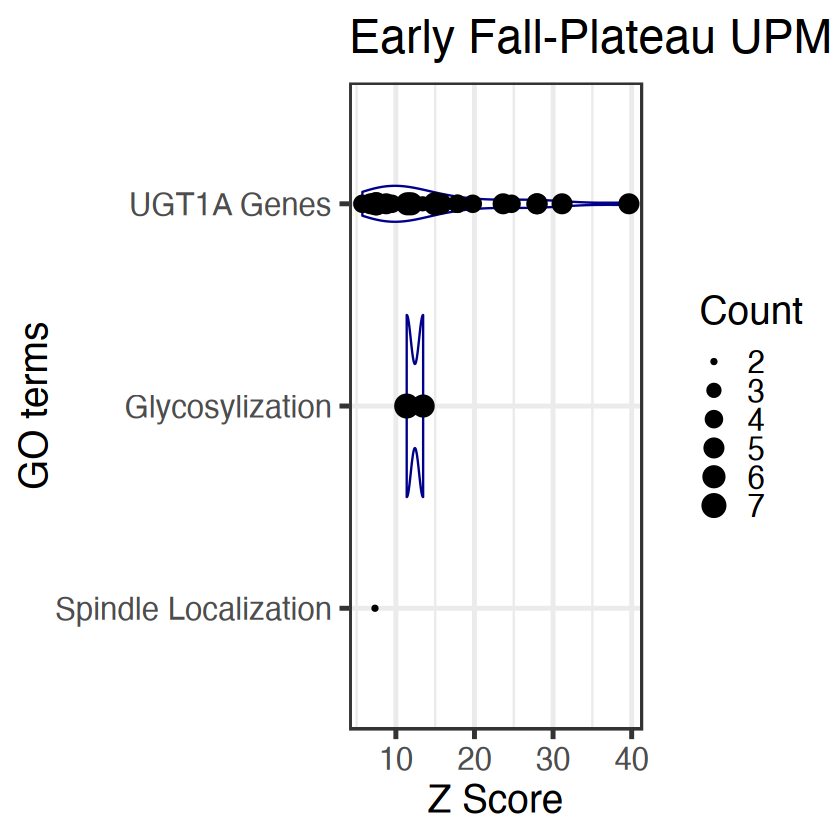

In [275]:
unique(as.data.frame(GO_EPR)$geneID)
GO_EPR[1:4,]
GO_EPR[GO_EPR$geneID == "CDK5RAP2/SPIRE2",]
#GO_EPR[grepl(c("OSBPL10|GALNT10|TIPARP|TFCP2L1|ALDH3A1"), GO_EPR$geneID) ,]




options(repr.plot.width=7, repr.plot.height=7)
#go_early_risep$Description
using = as.data.frame(GO_EPR)
using = using[using$Count > 1 & using$qvalue < 0.05,]
length(unique(using$Description))
#using[1:2,]
using$Group <- "Other"

using[grepl("UGT1A", using$geneID),]$Group <- "UGT1A Genes"
using[grepl("spindle", using$Description),]$Group <- "Spindle Localization"
using[grepl("glycosyl", using$Description),]$Group <- "Glycosylization"

testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
table(using$Group)
pEPR <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=23) + 
labs(y="GO terms", x="Z Score") + ggtitle("Early Rise-Plateau UPM")
pEPR
ggsave("GO_total_EPR_p10.pdf", pEPR, height=7, width=7)

[1] 14

ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>



               axonogenesis Epithelilium\nproliferation 
                          4                           5 
             ERBB signaling                 ERK cascade 
                          3                           2 

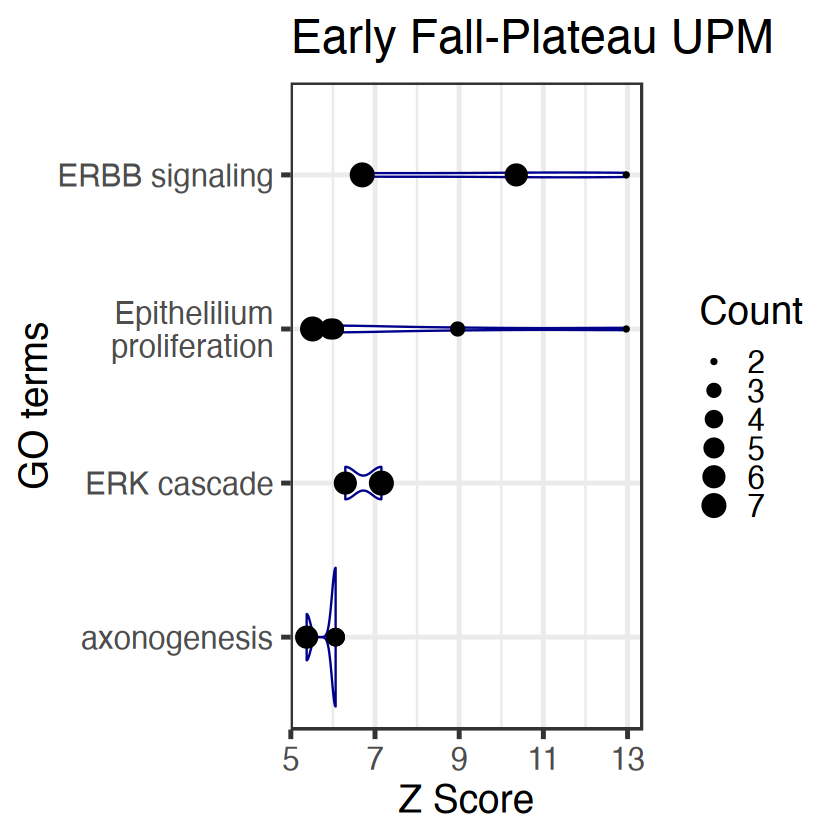

In [282]:

#go_early_risep$Description
using = as.data.frame(GO_EPF)
using = using[using$Count > 1 & using$qvalue < 0.05,]
length(unique(using$Description))
#using[1:2,]
using$Group <- "Other"

using[grepl("ERBB|intracellular receptor signaling", using$Description),]$Group <- "ERBB signaling"
using[grepl("epithelial cell proliferation|growth|pithelium development", using$Description),]$Group <- "Epithelilium\nproliferation"
using[grepl("ERK", using$Description),]$Group <- "ERK cascade"
using[grepl("axonogenesis|axon|neuron|neurogenesis", using$Description),]$Group <- "axonogenesis"

testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
table(using$Group)
pEPF <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=23) + 
labs(y="GO terms", x="Z Score") + ggtitle("Early Fall-Plateau UPM")
pEPF
ggsave("GO_total_EPF_p10.pdf", pEPF, height=7, width=7)

[1] 21

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0048864,BP,GO:0048864,stem cell development,4/69,86/18888,0.04651163,12.732053,6.602813,0.0002763935,0.03045856,0.02604887,SEMA3C/SEMA3A/EDN1/NRP2,4,Other
GO:0045178,CC,GO:0045178,basal part of cell,7/72,305/19894,0.02295082,6.341439,5.665584,0.0001167287,0.01762604,0.01695638,PHLDB2/EDN1/SLC11A2/SLCO3A1/CLDN7/ST14/CD38,7,Other



                  Cell growth Cell motility and\nAttachment 
                            4                             7 
 Mesenchymal\nDifferentiation            Muscle contraction 
                            1                             1 
                        Other          Outflow tract septum 
                            2                             2 
                     splicing              Vasoconstriction 
                            2                             2 

Warning message:
“Cannot compute density for groups with fewer than two datapoints.”
Warning message:
“Cannot compute density for groups with fewer than two datapoints.”


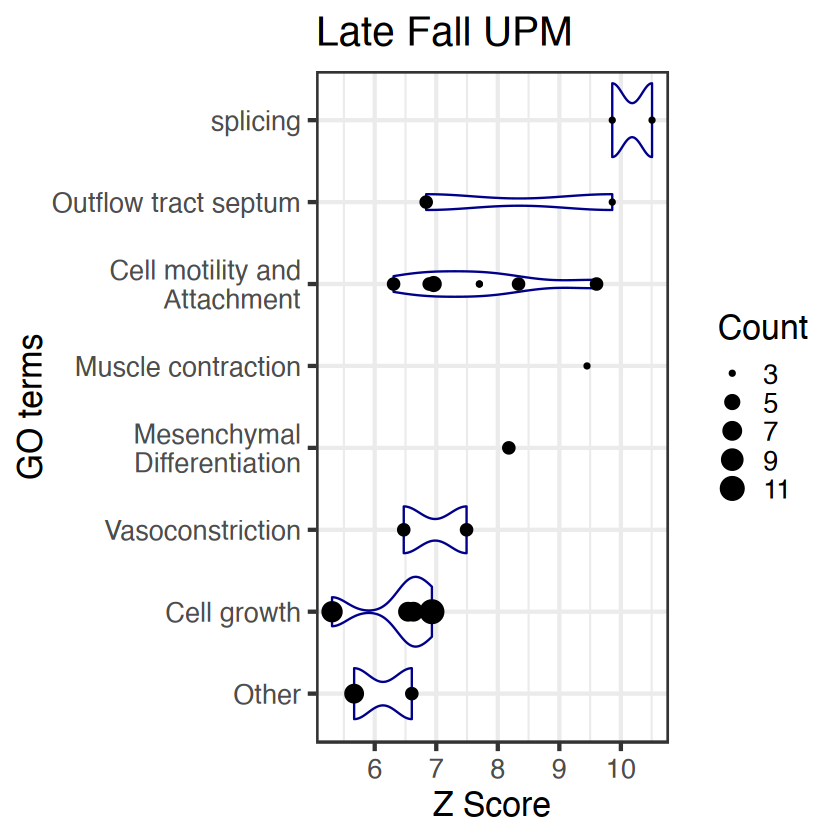

In [280]:


options(repr.plot.width=7)
#go_early_risep$Description
using = as.data.frame(GO_LF)
using = using[using$Count > 1 & using$qvalue < 0.03,]
length(unique(using$Description))
#using[1:2,]
using$Group <- "Other"
using[grepl("axon|chemorepellent|neural crest|semaphorin|neuron projection|cell migration|chemotaxis", using$Description),]$Group <- "Cell motility and\nAttachment"
using[grepl("mesenchymal", using$Description),]$Group <- "Mesenchymal\nDifferentiation"
using[grepl("splice", using$Description),]$Group <- "splicing"
using[grepl("muscle", using$Description),]$Group <- "Muscle contraction"
# using[grepl("wound healing", using$Description),]$Group <- "Neg regulation of Healing"
using[grepl("outflow tract", using$Description),]$Group <- "Outflow tract septum"
using[grepl("cell size|growth", using$Description),]$Group <- "Cell growth"
using[grepl("vasoconstriction", using$Description),]$Group <- "Vasoconstriction"

testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
table(using$Group)
pLF <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=20) + 
labs(y="GO terms", x="Z Score") + ggtitle("Late Fall UPM")
pLF
ggsave("GO_total_LF_p10.pdf", pLF, height=7, width=7)

[1] 36

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0015026,MF,GO:0015026,coreceptor activity,2/18,57/18522,0.035087719,36.105263,8.278862,0.001379280,0.02091908,0.01137301,ROR1/LRP5,2,Other
GO:0046982,MF,GO:0046982,protein heterodimerization activity,3/18,353/18522,0.008498584,8.745042,4.582277,0.004528253,0.03939580,0.02141819,UGT1A5/UGT1A4/UGT1A3,3,Other



             Alcohol metabolism    Estrogen/Steroid\nmetabolism 
                              2                               4 
                Glucuronidation Iso/Flavo/Terpenoid\nmetabolism 
                              7                               7 
                          Other   Porphyrin-related\nmetabolism 
                              2                               2 
          SNARE Membrane Fusion          Vitamin D&A metabolism 
                              2                               6 
                  Wnt Signaling             Xenobiotic response 
                              2                               2 

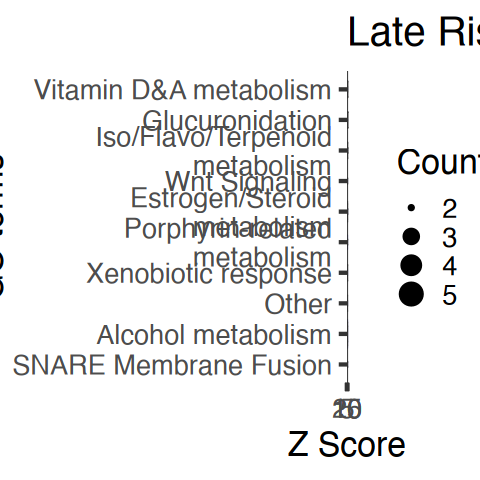

In [351]:

#go_early_risep$Description
using = as.data.frame(GO_LR)
using = using[using$Count > 1 & using$qvalue < 0.03,]
length(unique(using$Description))
#using[1:2,]
using$Group <- "Other"
using[grepl("vitamin|retino", using$Description),]$Group <- "Vitamin D&A metabolism"
using[grepl("flavonoid|terpenoid|isoprenoid", using$Description),]$Group <- "Iso/Flavo/Terpenoid\nmetabolism"
using[grepl("estrogen|steroid|hormone", using$Description),]$Group <- "Estrogen/Steroid\nmetabolism"
using[grepl("xenobiotic", using$Description),]$Group <- "Xenobiotic response"
using[grepl("porphyrin|tetrapyrrole", using$Description),]$Group <- "Porphyrin-related\nmetabolism"
using[grepl("glycosyltransferase|hexosyltransferase|glucuronidation|glucuronosyl|uronic acid|glucuronate", using$Description),]$Group <- "Glucuronidation"
using[grepl("Wnt", using$Description),]$Group <- "Wnt Signaling"
using[grepl("alcohol", using$Description),]$Group <- "Alcohol metabolism"
using[grepl("syntaxin|SNARE", using$Description),]$Group <- "SNARE Membrane Fusion"

testing = using[using$Group == "Other",]
testing[order(-testing$zScore),]
using$Max_call <- 0
for (group in unique(using$Group)) {
    filt = using[using$Group == group,]
    max_call = max(filt$zScore)
    using[using$Group == group,]$Max_call = max_call
    }
table(using$Group)
pLR <- ggplot(using, aes(x=zScore, y=reorder(Group, Max_call))) + geom_violin(color = "darkblue", drop=FALSE) + 
geom_point(color = "black", aes(size=Count)) + theme_bw(base_size=20) + 
labs(y="GO terms", x="Z Score") + ggtitle("Late Rise UPM")
pLR
ggsave("GO_total_LR_p10.pdf", pLR, height=7, width=7)

In [353]:
table(using$Group)
using[using$Group == "Glucuronidation",]


             Alcohol metabolism    Estrogen/Steroid\nmetabolism 
                              2                               4 
                Glucuronidation Iso/Flavo/Terpenoid\nmetabolism 
                              7                               7 
                          Other   Porphyrin-related\nmetabolism 
                              2                               2 
          SNARE Membrane Fusion          Vitamin D&A metabolism 
                              2                               6 
                  Wnt Signaling             Xenobiotic response 
                              2                               2 

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Group,Max_call
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>
GO:0052695,BP,GO:0052695,cellular glucuronidation,3/18,21/18888,0.14285714,149.90476,21.086214,9.561935e-07,0.0001966192,0.0001348722,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0006063,BP,GO:0006063,uronic acid metabolic process,3/18,26/18888,0.11538462,121.07692,18.922745,1.863689e-06,0.0001966192,0.0001348722,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0019585,BP,GO:0019585,glucuronate metabolic process,3/18,26/18888,0.11538462,121.07692,18.922745,1.863689e-06,0.0001966192,0.0001348722,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0015020,MF,GO:0015020,glucuronosyltransferase activity,3/18,34/18522,0.08823529,90.79412,16.344741,4.525413e-06,0.0004118126,0.0002238889,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0008194,MF,GO:0008194,UDP-glycosyltransferase activity,3/18,145/18522,0.02068966,21.28966,7.649922,3.517894e-04,0.0098930334,0.0053785144,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0016758,MF,GO:0016758,hexosyltransferase activity,3/18,196/18522,0.01530612,15.75000,6.474733,8.469259e-04,0.0154140510,0.0083801087,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621
GO:0016757,MF,GO:0016757,glycosyltransferase activity,3/18,268/18522,0.01119403,11.51866,5.409839,2.081005e-03,0.0236714281,0.0128693710,UGT1A5/UGT1A4/UGT1A3,3,Glucuronidation,21.08621


## Compare the calls and dynamics between WSP and UPM

In [348]:
names(WSP_10_time_sig)
#new_list = list()
WSP_comp_df = data.frame()
options(repr.plot.width=4, repr.plot.height=4)
pdf("./Barplots_UPMtoWSP.pdf", height=4, width=4)
for (timepoint in names(UPM_10_time_sig)) {
    default_fill = c("ER"="grey", "EF"="grey", "EPR"="grey", 
                     "EPF"="grey", "LR"="grey", "LF"="grey")
    default_fill[[timepoint]] = "blue"
    new_list = list()
    # compare to all the WSP ones
    ER_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["ER"]]))
    EF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EF"]]))
    EPR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPR"]]))
    EPF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPF"]]))
    LR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LR"]]))
    LF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LF"]]))
    # make df with relevant data
    add_comp_df = data.frame(list("UPM_method"=rep(timepoint, 6), 
                                  "WSP_Comparison"=c("ER", "EF", "EPR", "EPF", "LR", "LF"), 
                                 "Num_Shared"=c(ER_shared, EF_shared, 
                                               EPR_shared, EPF_shared, 
                                               LR_shared, LF_shared)))
    add_comp_df$Per_shared = add_comp_df$Num_Shared/length(UPM_10_time_sig[[timepoint]])*100
    WSP_comp_df = rbind(WSP_comp_df, add_comp_df)   
    p <- ggplot(add_comp_df, aes(factor(WSP_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared, 
                           fill=WSP_Comparison)) + 
    geom_col() + scale_fill_manual(values=default_fill) + 
    labs(x="WSP Gene Categories", y="% Shared", title=timepoint) + theme_minimal(base_size=20) +
    geom_text(aes(label = Num_Shared), 
            vjust = -0.5, size = 6) +  # adjust vjust and size as needed
    theme(axis.text.x=element_text(angle=90, hjust=1.4, vjust=.5), 
          panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.minor.y = element_blank(),
          legend.position="FALSE") +
    expand_limits(y = max(add_comp_df$Per_shared, na.rm = TRUE) * 1.1)  # add headroom above bars
    print(p)
    }
dev.off()
lapply(WSP_10_time_sig, length)

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

pdf 
  2

$ER
[1] 416

$EF
[1] 1527

$EPR
[1] 164

$EPF
[1] 1148

$LR
[1] 879

$LF
[1] 549

In [29]:
names(UPM_10_time_sig)
#new_list = list()
UPM_comp_df = data.frame()
options(repr.plot.width=4, repr.plot.height=4)
pdf("./Barplots_WSPtoUPM.pdf", height=4, width=4)
for (timepoint in names(UPM_10_time_sig)) {
    default_fill = c("ER"="grey", "EF"="grey", "EPR"="grey", 
                     "EPF"="grey", "LR"="grey", "LF"="grey")
    default_fill[[timepoint]] = "blue"
    new_list = list()
    # compare to all the WSP ones
    ER_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["ER"]]))
    EF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EF"]]))
    EPR_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EPR"]]))
    EPF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EPF"]]))
    LR_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["LR"]]))
    LF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["LF"]]))
    # make df with relevant data
    add_comp_df = data.frame(list("WSP_method"=rep(timepoint, 6), 
                                  "UPM_Comparison"=c("ER", "EF", "EPR", "EPF", "LR", "LF"), 
                                 "Num_Shared"=c(ER_shared, EF_shared, 
                                               EPR_shared, EPF_shared, 
                                               LR_shared, LF_shared)))
    add_comp_df$Per_shared = add_comp_df$Num_Shared/length(WSP_10_time_sig[[timepoint]])*100
    UPM_comp_df = rbind(UPM_comp_df, add_comp_df)   
    p <- ggplot(add_comp_df, aes(factor(UPM_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared, 
                           fill=UPM_Comparison)) + 
    geom_col() + scale_fill_manual(values=default_fill) + 
    labs(x="UPM Gene Categories", y="% Shared", title=timepoint) + theme_minimal(base_size=20) +
    geom_text(aes(label = Num_Shared), 
            vjust = -0.5, size = 6) +  # adjust vjust and size as needed
    theme(axis.text.x=element_text(angle=90, hjust=1.4, vjust=.5), 
          panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.minor.y = element_blank(),
          legend.position="FALSE") +
    expand_limits(y = max(add_comp_df$Per_shared, na.rm = TRUE) * 1.1)  # add headroom above bars
    print(p)
    }
dev.off()
lapply(UPM_10_time_sig, length)

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

pdf 
  2

$ER
[1] 1348

$EF
[1] 851

$EPR
[1] 25

$EPF
[1] 51

$LR
[1] 21

$LF
[1] 94

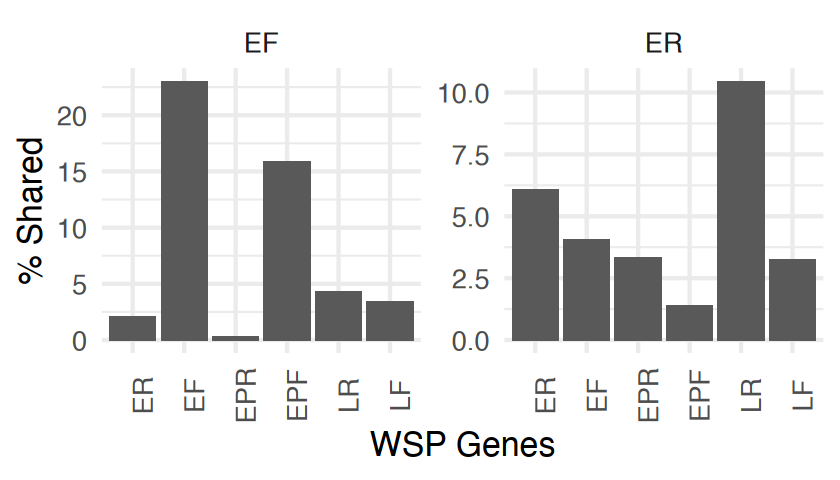

In [319]:
options(repr.plot.width=7, repr.plot.height=4)
for (timepoint in 
ggplot(WSP_comp_df[WSP_comp_df$UPM_method %in% c("ER", "EF"),], 
       aes(x=factor(WSP_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared)) + geom_col() +
theme_minimal(base_size=20) + facet_wrap(~UPM_method, scale="free_y") + labs(x="WSP Genes", y="% Shared") + 
theme(axis.text.x=element_text(angle=90))